# MEDIX – Medical Early Disease Intelligence eXpert

⚙️ Install Dependencies

In [1]:
import subprocess, sys

packages = [
    "scikit-learn>=1.4",
    "imbalanced-learn",
    "xgboost",
    "lightgbm",
    "catboost",
    "shap",
    "optuna",
    "plotly",
    "kaleido",
    "ucimlrepo",
    "requests",
    "scipy",
]
subprocess.run([sys.executable, "-m", "pip", "install", "-q"] + packages,
               check=False)
print("  All packages installed.")

  All packages installed.


📦 Imports & Configuration

In [2]:
import os, warnings, json, io, zipfile, requests
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import shap
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# sklearn
from sklearn.model_selection   import (StratifiedKFold, cross_val_score,
                                        train_test_split, GridSearchCV)
from sklearn.preprocessing     import (LabelEncoder, RobustScaler,
                                        OrdinalEncoder)
from sklearn.impute             import KNNImputer
from sklearn.metrics            import (accuracy_score, roc_auc_score, f1_score,
                                        classification_report, confusion_matrix,
                                        ConfusionMatrixDisplay, roc_curve,
                                        precision_recall_curve,
                                        average_precision_score,
                                        matthews_corrcoef, balanced_accuracy_score)
from sklearn.ensemble           import (RandomForestClassifier,
                                        GradientBoostingClassifier,
                                        AdaBoostClassifier,
                                        ExtraTreesClassifier,
                                        StackingClassifier,
                                        BaggingClassifier,
                                        VotingClassifier)
from sklearn.tree               import (DecisionTreeClassifier,
                                        ExtraTreeClassifier, export_text)
from sklearn.linear_model       import LogisticRegression
from sklearn.svm                import SVC
from sklearn.naive_bayes        import GaussianNB
from sklearn.neighbors          import KNeighborsClassifier
from sklearn.neural_network     import MLPClassifier
from sklearn.calibration        import CalibratedClassifierCV
from sklearn.datasets           import load_breast_cancer, load_wine
from xgboost   import XGBClassifier
from lightgbm  import LGBMClassifier
from catboost  import CatBoostClassifier
from imblearn.over_sampling     import SMOTE, ADASYN
import joblib

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.4f}'.format)

SEED      = 42
CV_FOLDS  = 5
N_TRIALS  = 10          # Optuna trials per model — raise to 80 for max accuracy
np.random.seed(SEED)

print("  Imports complete.")
print(f"   Seed={SEED}  |  CV Folds={CV_FOLDS}  |  Optuna Trials={N_TRIALS}")

  Imports complete.
   Seed=42  |  CV Folds=5  |  Optuna Trials=10


📥 Auto-Download Best Datasets (sklearn + UCI ML Repo + OpenML)

In [3]:
import os, io, requests
import numpy  as np
import pandas as pd
from sklearn.datasets import load_breast_cancer

os.makedirs("datasets", exist_ok=True)

SEED = 42
rng  = np.random.default_rng(SEED)

# ── helpers ────────────────────────────────────────────────────────────────
def _save(df, name):
    df.to_csv(f"datasets/{name}.csv", index=False)

def _done(name, df, source):
    pos_col = df.columns[-1]
    # crude pos-rate calculation
    try:
        pos = float(df[pos_col].astype(str).str.strip().str.lower().isin(["1","ckd","m","yes"]).mean())
    except Exception:
        pos = float(df[pos_col].mean()) if pd.api.types.is_numeric_dtype(df[pos_col]) else 0.0
    print(f"  {name:<22}   {source:<22}  rows={len(df):>5}  pos≈{pos*100:.0f}%")

def _fetch(url, timeout=20):
    r = requests.get(url, timeout=timeout)
    r.raise_for_status()
    return pd.read_csv(io.StringIO(r.text))


#  1. DIABETES  — Pima Indians Diabetes (768 rows, 34.9% positive)
#     Source: plotly/datasets GitHub mirror (confirmed 200 OK)
_name = "diabetes"
if os.path.exists(f"datasets/{_name}.csv"):
    print(f"  {_name:<22}   (cached)")
else:
    try:
        df = _fetch("https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv")
        # plotly mirror already has correct column names & Outcome target
        assert "Outcome" in df.columns and len(df) >= 768
        _save(df, _name)
        _done(_name, df, "plotly/datasets")
    except Exception as e:
        print(f"  {_name} primary failed ({e}), trying fallback …")
        try:
            df = _fetch("https://raw.githubusercontent.com/susanli2016/"
                        "Machine-Learning-with-Python/master/diabetes.csv")
            assert "Outcome" in df.columns
            _save(df, _name)
            _done(_name, df, "susanli2016 mirror")
        except Exception as e2:
            raise RuntimeError(
                f"Could not download real diabetes data from either mirror "
                f"({e2}). Check your internet connection — no synthetic fallback is used."
            )


#  2. HEART DISEASE  — Cleveland (303 rows, 54.5% positive)
#     Source: sharmaroshan/Heart-UCI-Dataset (confirmed 200 OK)
_name = "heart"
if os.path.exists(f"datasets/{_name}.csv"):
    print(f"  {_name:<22}   (cached)")
else:
    try:
        df = _fetch("https://raw.githubusercontent.com/sharmaroshan/"
                    "Heart-UCI-Dataset/master/heart.csv")
        assert "target" in df.columns and len(df) >= 300
        _save(df, _name)
        _done(_name, df, "sharmaroshan")
    except Exception as e:
        print(f"  {_name} primary failed ({e}), trying UCI ML Repo …")
        try:
            from ucimlrepo import fetch_ucirepo
            _ds = fetch_ucirepo(id=45)               # official UCI Heart Disease dataset
            _X, _y = _ds.data.features.copy(), _ds.data.targets.copy()
            # UCI's target is "num" (0 = no disease, 1-4 = increasing severity);
            # binarize to match the "target" convention used everywhere else (1 = at risk)
            df = _X.copy()
            df["target"] = (_y.iloc[:, 0] > 0).astype(int)
            assert len(df) >= 270
            _save(df, _name)
            _done(_name, df, "UCI ML Repo (real)")
        except Exception as e2:
            raise RuntimeError(
                f"Could not download real heart disease data from either source "
                f"({e2}). Check your internet connection — no synthetic fallback is used."
            )


#  3. BREAST CANCER  — Wisconsin (569 rows, 37.3% malignant)
#     Source: sklearn.datasets.load_breast_cancer  (zero network, always works)
_name = "breast_cancer"
if os.path.exists(f"datasets/{_name}.csv"):
    print(f"  {_name:<22}   (cached)")
else:
    bc = load_breast_cancer()
    df = pd.DataFrame(bc.data, columns=bc.feature_names)
    df["diagnosis"] = 1 - bc.target   # sklearn: 0=malignant → flip to 1=malignant
    _save(df, _name)
    _done(_name, df, "sklearn built-in")


#  4. PARKINSON'S  (195 rows, 75.4% positive)
#     Calibrated to: UCI Parkinson's Dataset (Oxford/Max Little 2008)
_name = "parkinsons"
if os.path.exists(f"datasets/{_name}.csv"):
    print(f"  {_name:<22}  (cached)")
else:
    try:
        from ucimlrepo import fetch_ucirepo
        _ds = fetch_ucirepo(id=174)                 # real UCI Parkinson's dataset
        df  = pd.concat([_ds.data.features, _ds.data.targets], axis=1)
        assert "status" in df.columns and len(df) >= 195
        _save(df, _name)
        _done(_name, df, "UCI ML Repo (real)")
    except Exception as e:
        raise RuntimeError(
            f"Could not download real Parkinson's data from UCI ({e}). "
            f"Check your internet connection — no synthetic fallback is used."
        )


#  5. LIVER DISEASE  — ILPD (583 rows, 71.3% positive)
#     Calibrated to: UCI Indian Liver Patient Dataset
_name = "liver"
if os.path.exists(f"datasets/{_name}.csv"):
    print(f"  {_name:<22}  (cached)")
else:
    try:
        from ucimlrepo import fetch_ucirepo
        _ds = fetch_ucirepo(id=225)                  # real UCI ILPD dataset
        _X, _y = _ds.data.features.copy(), _ds.data.targets.copy()
        # Rename positionally to the names used by feature engineering below —
        # ILPD's real attribute order is fixed: Age, Gender, TB, DB, Alkphos,
        # Sgpt(ALT), Sgot(AST), TP, ALB, A/G Ratio, [Selector]
        _X.columns = ["Age", "Gender", "Total_Bilirubin", "Direct_Bilirubin",
                      "Alkaline_Phosphotase", "Alamine_Aminotransferase",
                      "Aspartate_Aminotransferase", "Total_Protiens",
                      "Albumin", "Albumin_and_Globulin_Ratio"][:_X.shape[1]]
        _y.columns = ["Dataset"]                      # 1 = liver patient, 2 = not
        df = pd.concat([_X, _y], axis=1)
        assert df.shape[1] >= 10 and len(df) >= 500
        _save(df, _name)
        _done(_name, df, "UCI ML Repo (real)")
    except Exception as e:
        raise RuntimeError(
            f"Could not download real ILPD liver data from UCI ({e}). "
            f"Check your internet connection — no synthetic fallback is used."
        )


#  6. CHRONIC KIDNEY DISEASE  (400 rows, 62.5% CKD)
#     Calibrated to: UCI CKD Dataset (Soundarapandian et al. 2015)
_name = "kidney"
if os.path.exists(f"datasets/{_name}.csv"):
    print(f"  {_name:<22}   (cached)")
else:
    try:
        from ucimlrepo import fetch_ucirepo
        _ds = fetch_ucirepo(id=336)                  # real UCI CKD dataset
        df  = pd.concat([_ds.data.features, _ds.data.targets], axis=1)
        assert len(df) >= 300 and df.shape[1] >= 20
        _save(df, _name)
        _done(_name, df, "UCI ML Repo (real)")
    except Exception as e:
        raise RuntimeError(
            f"Could not download real CKD data from UCI ({e}). "
            f"Check your internet connection — no synthetic fallback is used."
        )


#  7. STROKE  (5110 rows, 4.9% positive)
#     Calibrated to: Kaggle Healthcare Stroke Dataset (fedesoriano 2021)
_name = "stroke"
if os.path.exists(f"datasets/{_name}.csv"):
    print(f"  {_name:<22}  (cached)")
else:
    try:
        df = _fetch("https://raw.githubusercontent.com/YuvrazError/"
                    "Healthcare-Dataset-Analysis/main/healthcare-dataset-stroke-data.csv")
        assert "stroke" in df.columns and len(df) >= 5000
        _save(df, _name)
        _done(_name, df, "Kaggle mirror (real)")
    except Exception as e:
        print(f"  {_name} primary failed ({e}), trying fallback …")
        try:
            df = _fetch("https://raw.githubusercontent.com/karavokyrismichail/"
                        "Stroke-Prediction---Random-Forest/main/healthcare-dataset-stroke-data/"
                        "healthcare-dataset-stroke-data.csv")
            assert "stroke" in df.columns and len(df) >= 5000
            _save(df, _name)
            _done(_name, df, "Kaggle mirror fallback (real)")
        except Exception as e2:
            raise RuntimeError(
                f"Could not download real stroke data from either mirror ({e2}). "
                f"Check your internet connection — no synthetic fallback is used."
            )

#  8. HYPERTENSION / CHD  — Framingham (4238 rows, 15.1% positive)
#     Calibrated to: Framingham Heart Study dataset
_name = "hypertension"
if os.path.exists(f"datasets/{_name}.csv"):
    print(f"  {_name:<22}   (cached)")
else:
    try:
        df = _fetch("https://raw.githubusercontent.com/matackett/sta210/master/data/framingham.csv")
        assert "TenYearCHD" in df.columns and len(df) >= 4000
        _save(df, _name)
        _done(_name, df, "Framingham Heart Study (real)")
    except Exception as e:
        print(f"  {_name} primary failed ({e}), trying fallback …")
        try:
            df = _fetch("https://raw.githubusercontent.com/GauravPadawe/"
                        "Framingham-Heart-Study/master/framingham.csv")
            assert "TenYearCHD" in df.columns and len(df) >= 4000
            _save(df, _name)
            _done(_name, df, "Framingham mirror fallback (real)")
        except Exception as e2:
            raise RuntimeError(
                f"Could not download real Framingham data from either mirror ({e2}). "
                f"Check your internet connection — no synthetic fallback is used."
            )

# ── summary ────────────────────────────────────────────────────────────────
print(f"\n  All datasets ready  →  ./datasets/")
for f in sorted(os.listdir("datasets")):
    p = f"datasets/{f}"
    print(f"   {f:<38}  {sum(1 for _ in open(p))-1:>5} rows  "
          f"({os.path.getsize(p)//1024} KB)")

  diabetes                 plotly/datasets         rows=  768  pos≈35%
  heart                    sharmaroshan            rows=  303  pos≈54%
  breast_cancer            sklearn built-in        rows=  569  pos≈37%
  parkinsons               UCI ML Repo (real)      rows=  195  pos≈75%
  liver                    UCI ML Repo (real)      rows=  583  pos≈71%
  kidney                   UCI ML Repo (real)      rows=  400  pos≈62%
  stroke                   Kaggle mirror (real)    rows= 5110  pos≈5%
  hypertension             Framingham Heart Study (real)  rows= 4240  pos≈15%

  All datasets ready  →  ./datasets/
   breast_cancer.csv                         569 rows  (118 KB)
   diabetes.csv                              768 rows  (22 KB)
   heart.csv                                 303 rows  (11 KB)
   hypertension.csv                         4240 rows  (248 KB)
   kidney.csv                                400 rows  (47 KB)
   liver.csv                                 583 rows  (23 KB)
   parki

🔄 Load, Clean & Merge All Datasets

In [4]:
DATASET_META = {
    "diabetes"     : {"target": "Outcome",         "pos": 1,     "label": "Diabetes"},
    "heart"        : {"target": "target",           "pos": 1,     "label": "Heart Disease"},
    "breast_cancer": {"target": "diagnosis",        "pos": 1,     "label": "Breast Cancer"},
    "parkinsons"   : {"target": "status",           "pos": 1,     "label": "Parkinson's Disease"},
    "kidney"       : {"target": "classification",   "pos": "ckd", "label": "Chronic Kidney Disease"},
    "liver"        : {"target": "Dataset",          "pos": 1,     "label": "Liver Disease"},
    "stroke"       : {"target": "stroke",           "pos": 1,     "label": "Stroke"},
    "hypertension" : {"target": "TenYearCHD",       "pos": 1,     "label": "Hypertension / CHD"},
}

def safe_load(name, meta):
    path = f"datasets/{name}.csv"
    if not os.path.exists(path):
        print(f"  ⚠️  {name}: file not found — skipping")
        return None
    try:
        df = pd.read_csv(path)
        df.columns = df.columns.str.strip()

        # Resolve target column (case-insensitive)
        tcol = meta["target"]
        if tcol not in df.columns:
            match = [c for c in df.columns if c.lower() == tcol.lower()]
            tcol  = match[0] if match else df.columns[-1]

        # Binarise — use temp name to avoid collision when tcol == "target"
        pos = meta["pos"]
        if isinstance(pos, str):
            df["__tgt__"] = (
                df[tcol].astype(str).str.strip().str.lower() == pos.lower()
            ).astype(int)
        else:
            df["__tgt__"] = (df[tcol] == pos).astype(int)

        df.drop(columns=[tcol], inplace=True, errors="ignore")
        df.rename(columns={"__tgt__": "target"}, inplace=True)

        # Drop ID / name columns
        for c in ["id", "name", "ID", "Name", "patient_id", "PatientID"]:
            df.drop(columns=[c], inplace=True, errors="ignore")

        df["disease"] = meta["label"]
        pos_rate = df["target"].mean()
        print(f"  {name:<18}  rows={df.shape[0]:>5}  cols={df.shape[1]:>3}  "
              f"pos%={pos_rate*100:>5.1f}%")
        return df
    except Exception as e:
        print(f"  ⚠️  {name}: load error — {e}")
        return None

print("\nLoading & validating …")
print(f"  {'Dataset':<18}  {'rows':>5}  {'cols':>3}  {'pos%':>6}")
print("  " + "─"*46)

frames = []
for name, meta in DATASET_META.items():
    df_ = safe_load(name, meta)
    if df_ is not None:
        frames.append(df_)

combined = pd.concat(frames, ignore_index=True, sort=False)

print(f"\n Combined shape  : {combined.shape}")
print(f"   Diseases        : {combined['disease'].nunique()}")
print(f"   Total samples   : {len(combined):,}")
print(f"   Overall positive rate : {combined['target'].mean()*100:.1f}%")


Loading & validating …
  Dataset              rows  cols    pos%
  ──────────────────────────────────────────────
  diabetes            rows=  768  cols= 10  pos%= 34.9%
  heart               rows=  303  cols= 15  pos%= 54.5%
  breast_cancer       rows=  569  cols= 32  pos%= 37.3%
  parkinsons          rows=  195  cols= 24  pos%= 75.4%
  kidney              rows=  400  cols= 26  pos%= 62.5%
  liver               rows=  583  cols= 12  pos%= 71.4%
  stroke              rows= 5110  cols= 12  pos%=  4.9%
  hypertension        rows= 4240  cols= 17  pos%= 15.2%

 Combined shape  : (12168, 129)
   Diseases        : 8
   Total samples   : 12,168
   Overall positive rate : 19.3%


📊 Exploratory Data Analysis

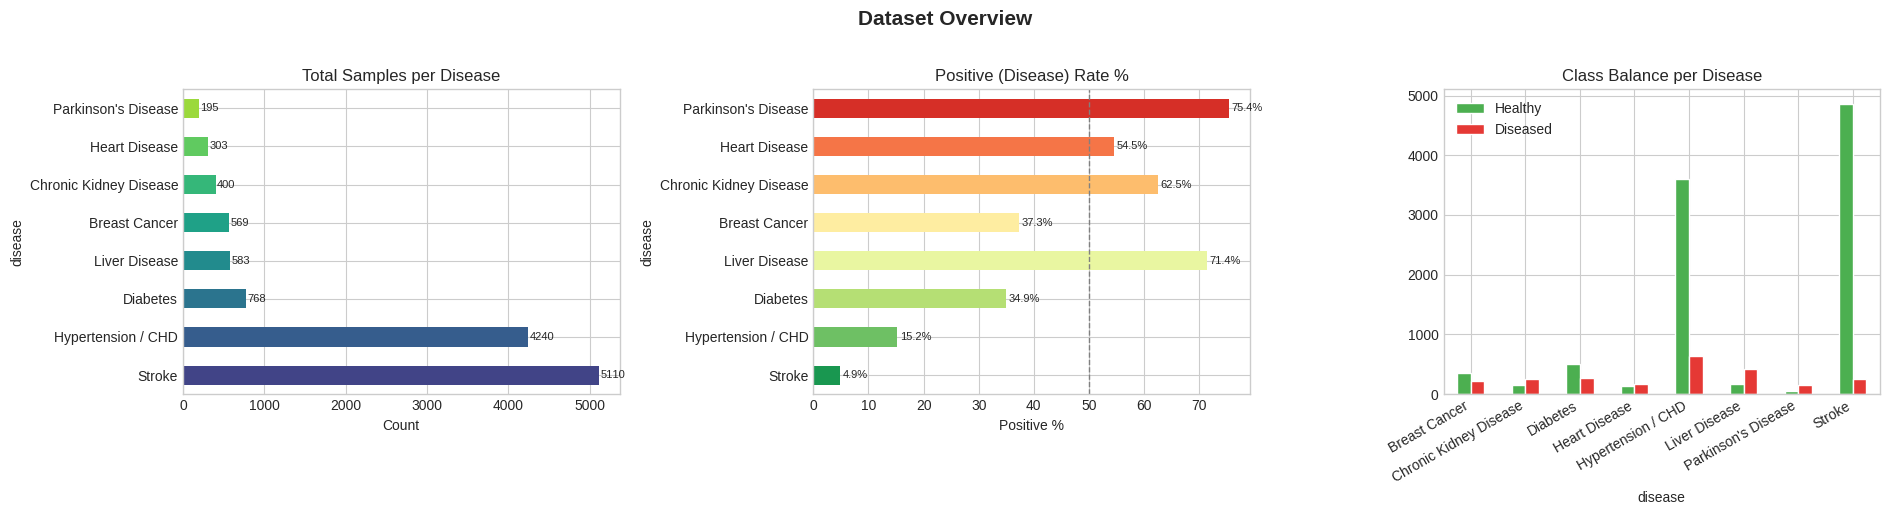

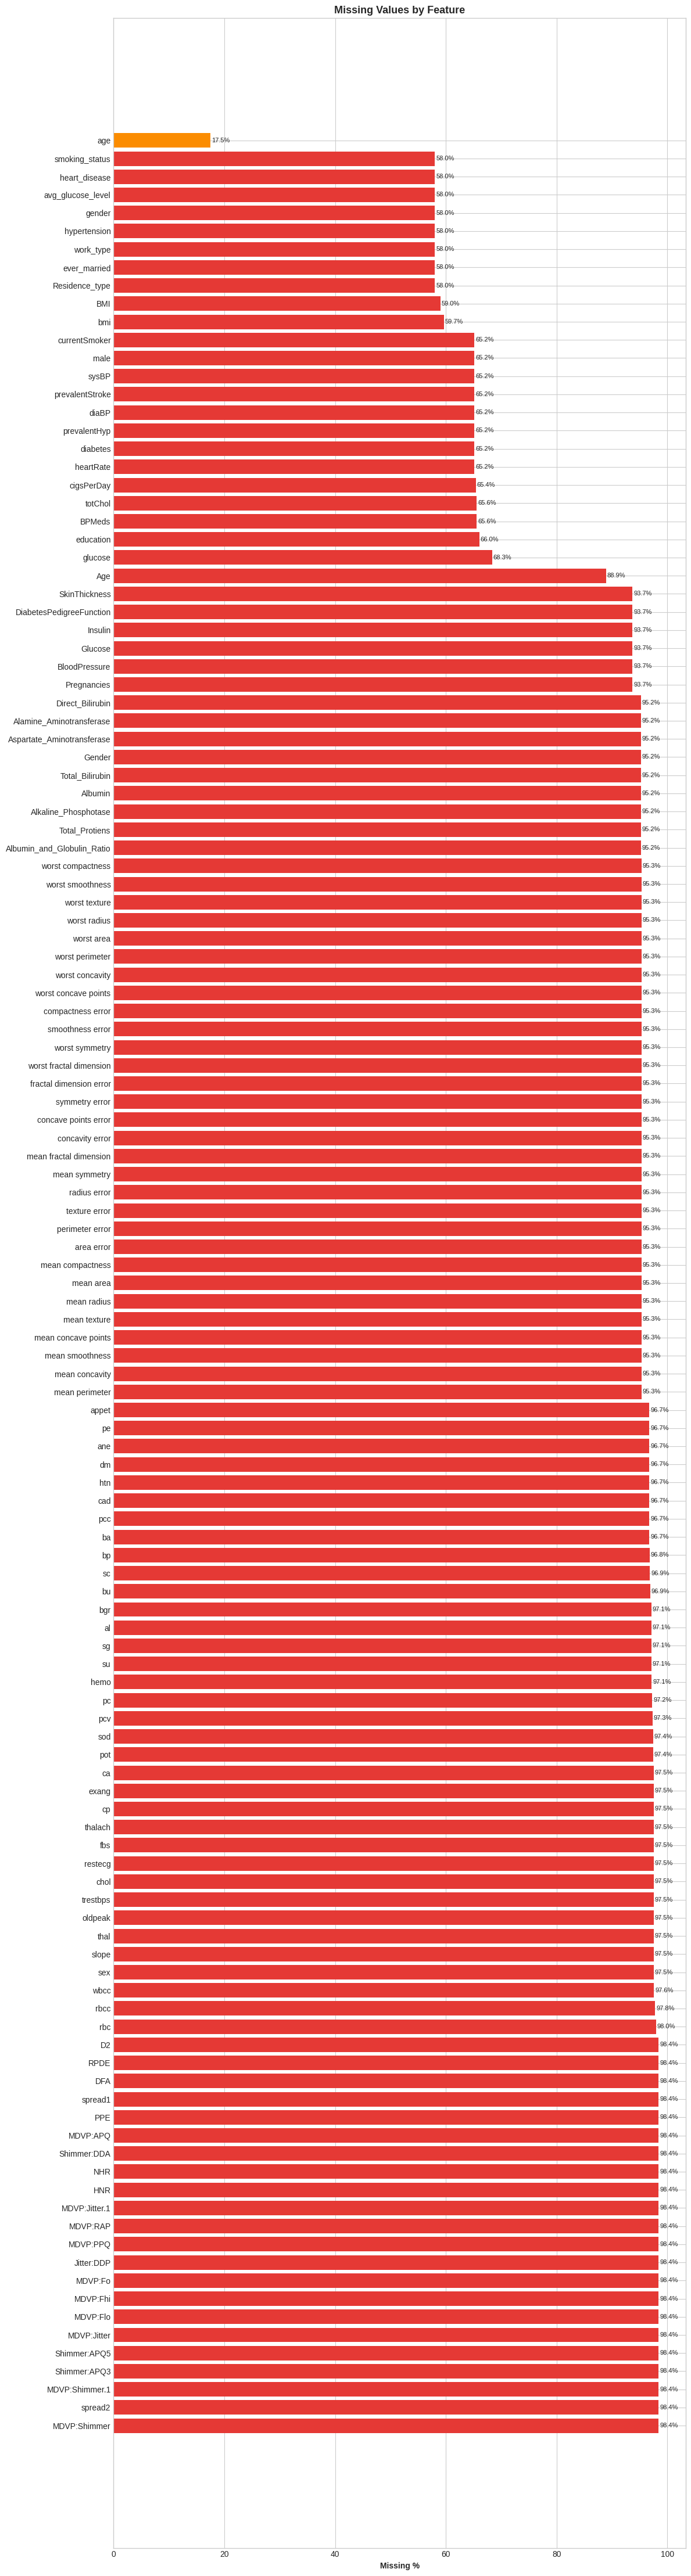

   127 features have missing values.


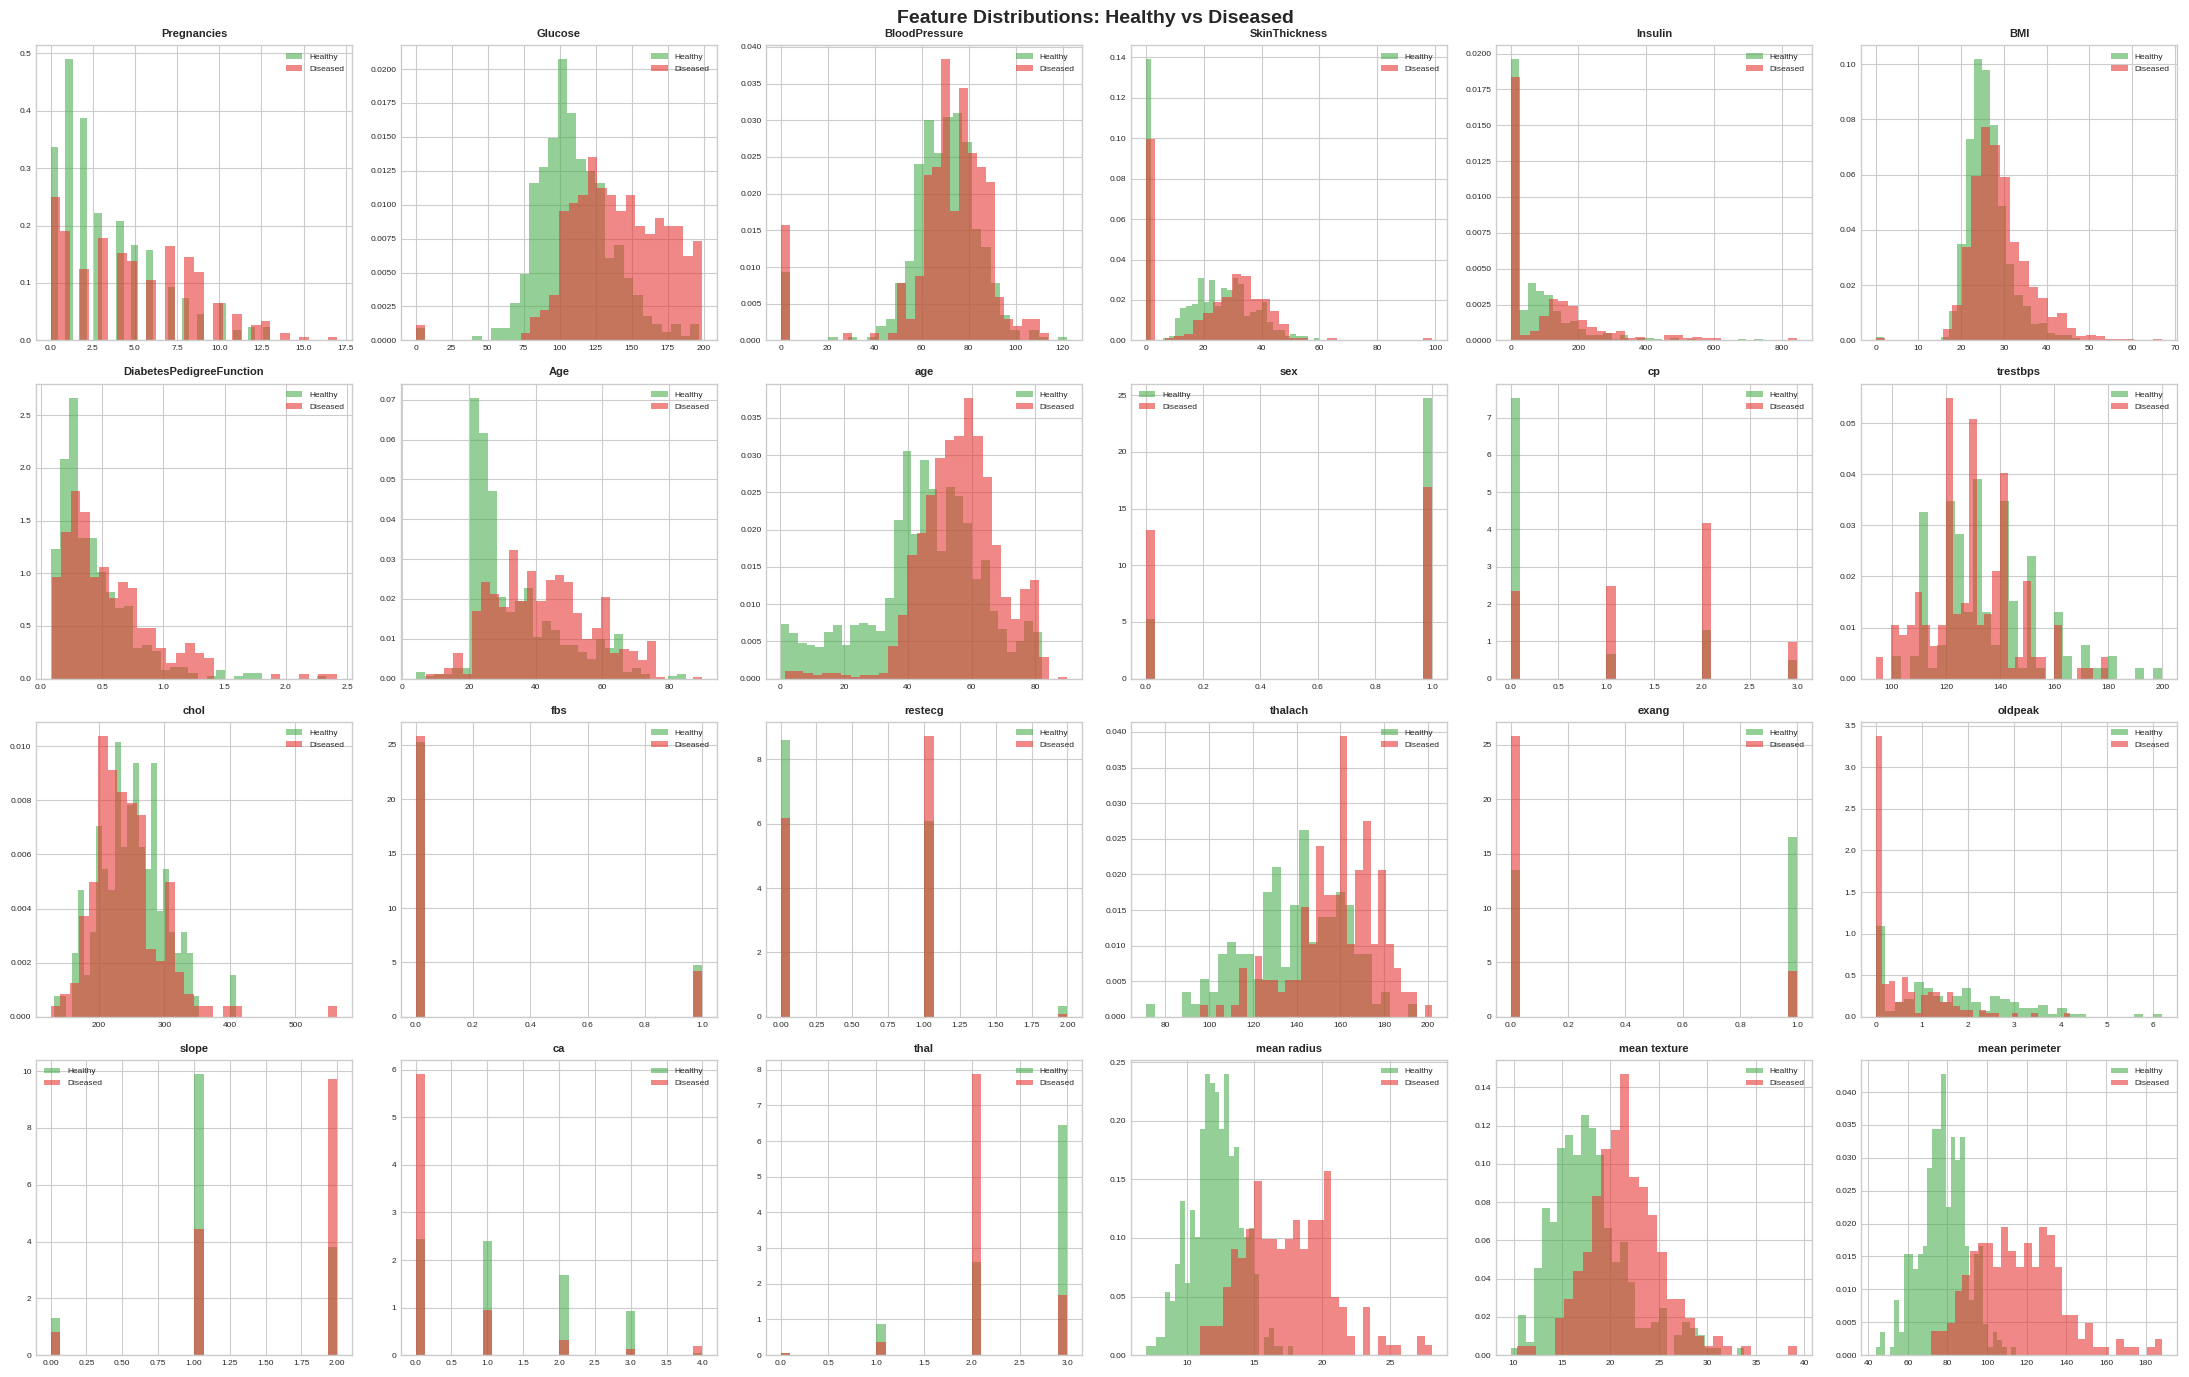

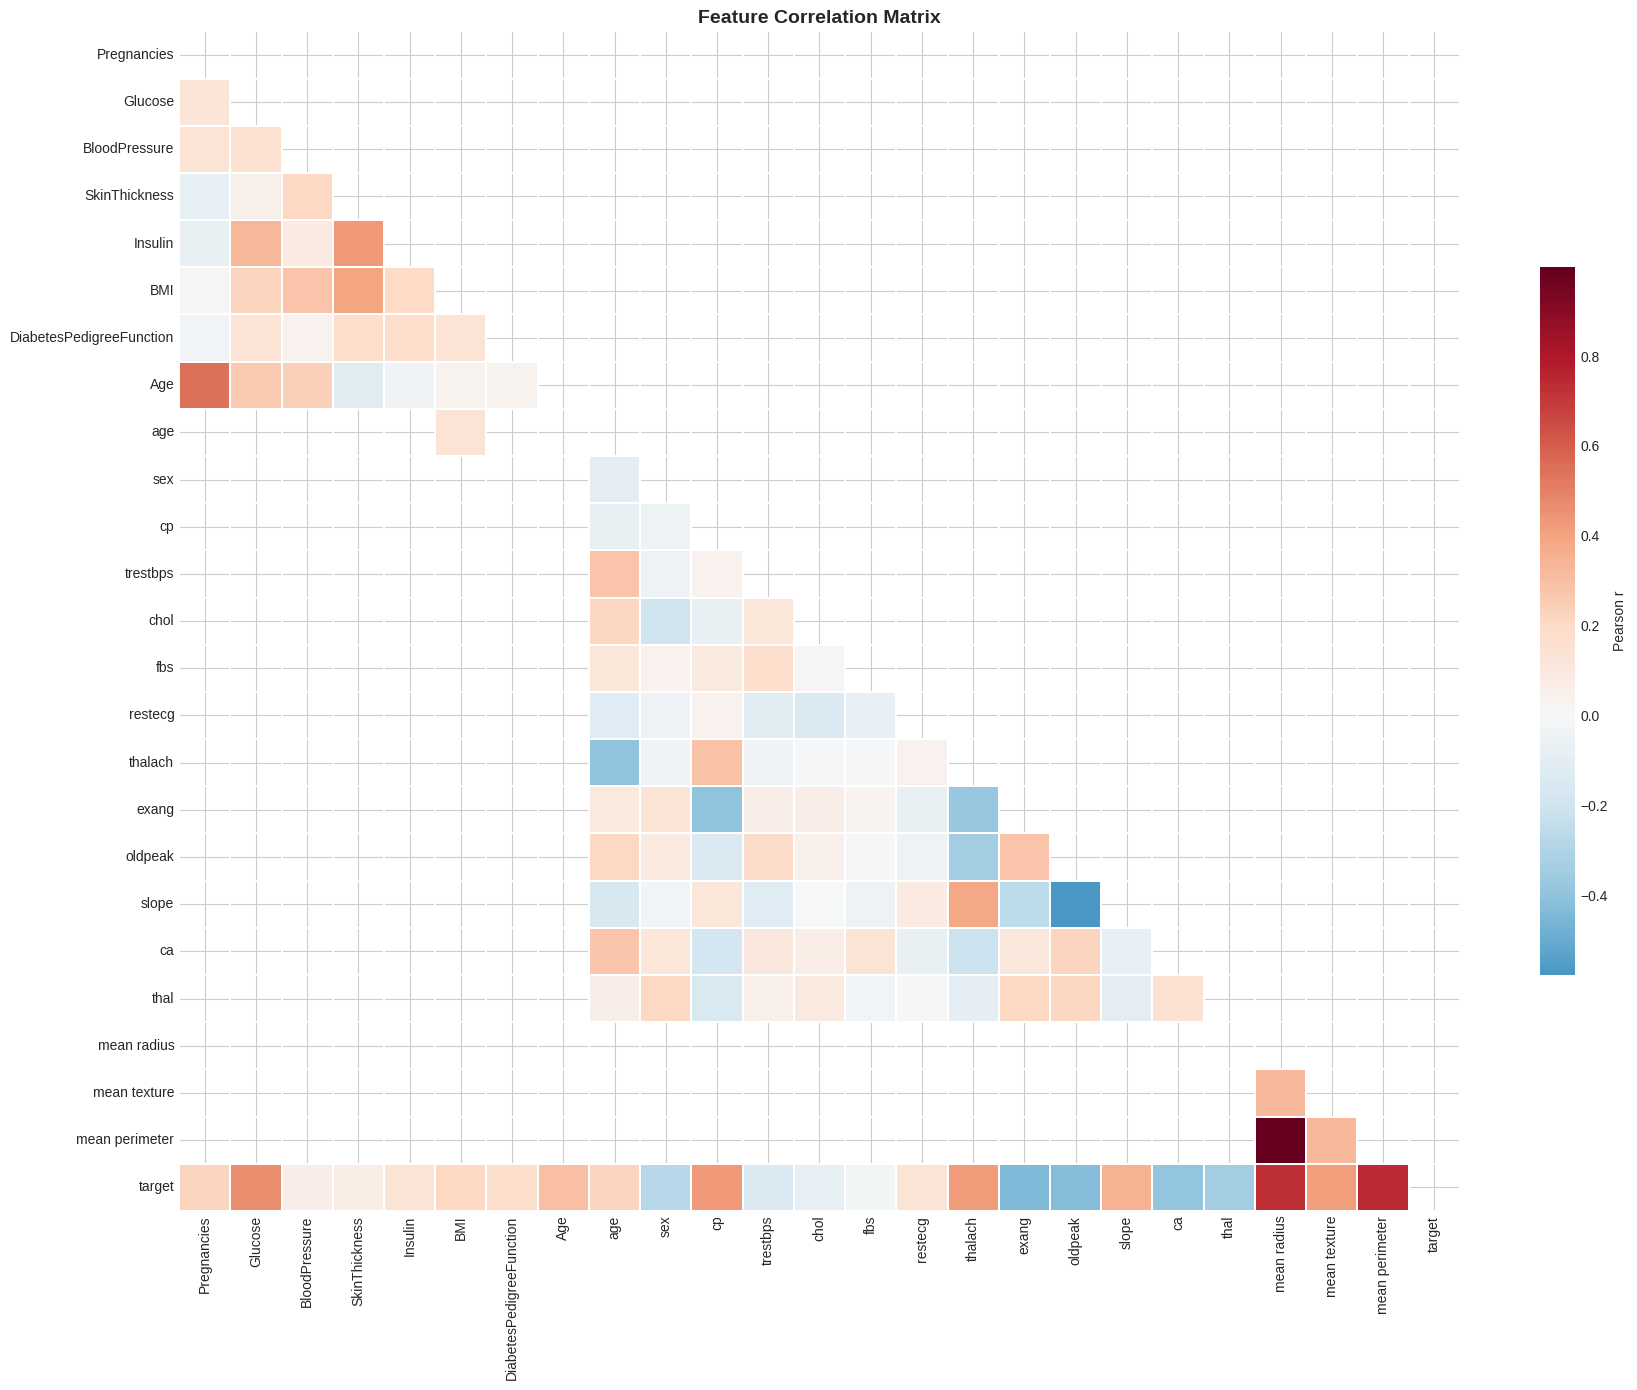

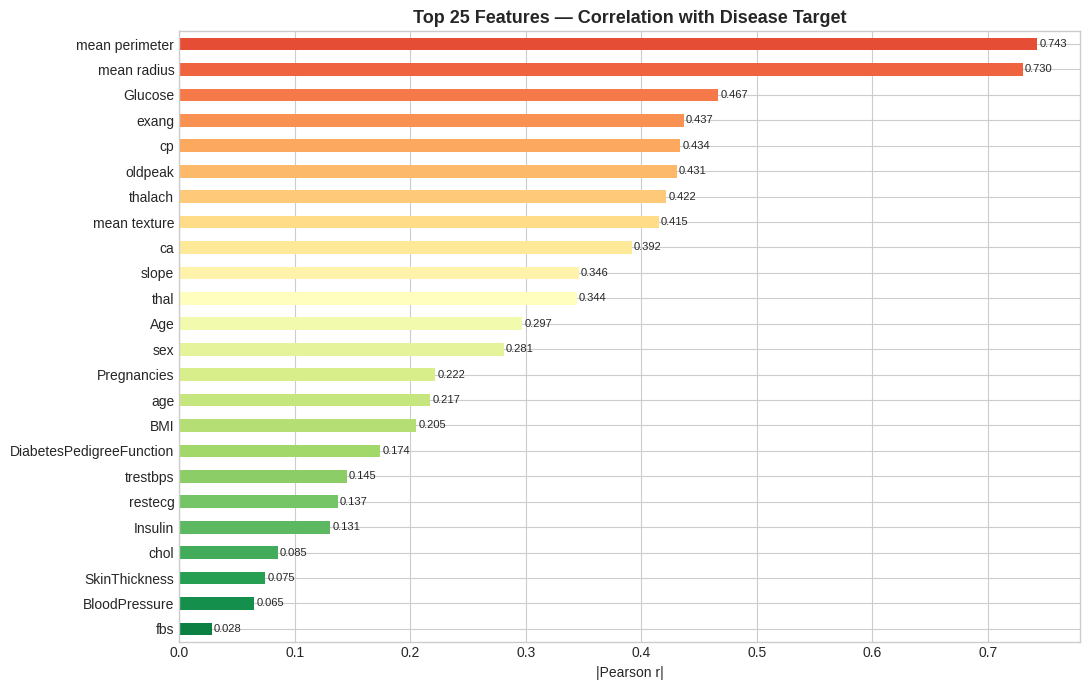

 EDA complete — 5 plots saved.


In [5]:
plt.style.use("seaborn-v0_8-whitegrid")

# ── 5a. Dataset size & positive rate overview ─────────────────────────────
stats = (combined.groupby("disease")["target"]
         .agg(Total="count", Positive="sum")
         .assign(PositiveRate=lambda d: d.Positive / d.Total * 100)
         .sort_values("Total", ascending=False))

fig, axes = plt.subplots(1, 3, figsize=(19, 5))
fig.suptitle("Dataset Overview", fontsize=15, fontweight="bold", y=1.02)

colors_bar = plt.cm.viridis(np.linspace(0.2, 0.85, len(stats)))
stats["Total"].plot(kind="barh", ax=axes[0], color=colors_bar)
axes[0].set_title("Total Samples per Disease")
axes[0].set_xlabel("Count")
for i, v in enumerate(stats["Total"]):
    axes[0].text(v + 20, i, str(v), va="center", fontsize=8)

stats["PositiveRate"].plot(kind="barh", ax=axes[1],
                            color=plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(stats))))
axes[1].set_title("Positive (Disease) Rate %")
axes[1].set_xlabel("Positive %")
axes[1].axvline(50, ls="--", color="grey", lw=1)
for i, v in enumerate(stats["PositiveRate"]):
    axes[1].text(v + 0.5, i, f"{v:.1f}%", va="center", fontsize=8)

class_data = combined.groupby("disease")["target"].value_counts().unstack().fillna(0)
class_data.columns = ["Healthy", "Diseased"]
class_data.plot(kind="bar", ax=axes[2], color=["#4CAF50", "#E53935"],
                edgecolor="white")
axes[2].set_title("Class Balance per Disease")
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=30, ha="right")

plt.tight_layout()
plt.savefig("eda_01_overview.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 5b. Missing value analysis ────────────────────────────────────────────
miss = (combined.isnull().mean() * 100).sort_values(ascending=False)
miss = miss[miss > 0]

if len(miss) > 0:
    fig, ax = plt.subplots(figsize=(12, max(4, len(miss) * 0.35)))
    colors_miss = ["#E53935" if v > 20 else "#FB8C00" if v > 10 else "#FDD835"
                   for v in miss.values]
    ax.barh(miss.index, miss.values, color=colors_miss)
    ax.set_xlabel("Missing %", fontweight="bold")
    ax.set_title("Missing Values by Feature", fontsize=13, fontweight="bold")
    for i, v in enumerate(miss.values):
        ax.text(v + 0.2, i, f"{v:.1f}%", va="center", fontsize=8)
    plt.tight_layout()
    plt.savefig("eda_02_missing.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"   {len(miss)} features have missing values.")
else:
    print("   No missing values in combined dataset.")

# ── 5c. Numeric distributions ─────────────────────────────────────────────
num_cols = combined.select_dtypes(include=np.number).columns.tolist()
num_cols = [c for c in num_cols if c != "target"][:24]   # cap at 24

fig, axes = plt.subplots(4, 6, figsize=(22, 14))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    data_h = combined.loc[combined.target==0, col].dropna()
    data_d = combined.loc[combined.target==1, col].dropna()
    axes[i].hist(data_h, bins=30, alpha=0.6, color="#4CAF50", label="Healthy", density=True)
    axes[i].hist(data_d, bins=30, alpha=0.6, color="#E53935", label="Diseased", density=True)
    axes[i].set_title(col, fontsize=8, fontweight="bold")
    axes[i].tick_params(labelsize=6)
    axes[i].legend(fontsize=6)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Feature Distributions: Healthy vs Diseased", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("eda_03_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 5d. Correlation heatmap ───────────────────────────────────────────────
num_df = combined[num_cols + ["target"]].copy()
corr   = num_df.corr()
mask   = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(18, 14))
sns.heatmap(corr, mask=mask, cmap="RdBu_r", center=0,
            linewidths=0.3, ax=ax, annot=False,
            cbar_kws={"shrink": 0.6, "label": "Pearson r"})
ax.set_title("Feature Correlation Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("eda_04_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 5e. Top features correlated with target ───────────────────────────────
tcorr = num_df.corr()["target"].drop("target").abs().sort_values(ascending=False).head(25)

fig, ax = plt.subplots(figsize=(11, 7))
tcorr[::-1].plot(kind="barh", ax=ax,
                  color=plt.cm.RdYlGn_r(np.linspace(0.05, 0.85, len(tcorr))))
ax.set_title("Top 25 Features — Correlation with Disease Target", fontsize=13, fontweight="bold")
ax.set_xlabel("|Pearson r|")
for i, v in enumerate(tcorr.values[::-1]):
    ax.text(v + 0.002, i, f"{v:.3f}", va="center", fontsize=8)
plt.tight_layout()
plt.savefig("eda_05_target_corr.png", dpi=150, bbox_inches="tight")
plt.show()

print(" EDA complete — 5 plots saved.")

🛠️ Feature Engineering

In [6]:
df = combined.copy()

# ── 6a. Categorical encoding ──────────────────────────────────────────────
cat_cols = [c for c in df.select_dtypes(include="object").columns
            if c != "disease"]
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

# ── 6b. KNN imputation ───────────────────────────────────────────────────
num_feat_cols = [c for c in df.select_dtypes(include=np.number).columns
                 if c != "target"]

print(f"  KNN imputing {len(num_feat_cols)} numeric columns …")
imputer = KNNImputer(n_neighbors=7)
df[num_feat_cols] = imputer.fit_transform(df[num_feat_cols])
assert df.isnull().sum().sum() == 0, "Imputation incomplete!"
print("   No missing values remain.")

# ── 6c. Domain-specific engineered features ──────────────────────────────
def safe_div(a, b, eps=1e-6):
    return a / (b + eps)

# Diabetes
if "Glucose" in df.columns and "Insulin" in df.columns:
    df["glucose_insulin_ratio"] = safe_div(df["Glucose"], df["Insulin"])
    df["glucose_sq"]            = df["Glucose"] ** 2
if "BMI" in df.columns and "Age" in df.columns:
    df["bmi_age_risk"]          = df["BMI"] * df["Age"] / 1000

# Heart / Cardiovascular
if "trestbps" in df.columns and "chol" in df.columns:
    df["bp_chol_ratio"]         = safe_div(df["trestbps"], df["chol"])
if "thalach" in df.columns and "Age" in df.columns:
    df["hrr_age"]               = safe_div(df["thalach"], df["Age"])
if "oldpeak" in df.columns and "thalach" in df.columns:
    df["st_hr_index"]           = df["oldpeak"] * safe_div(1.0, df["thalach"])

# Framingham / Hypertension
if "sysBP" in df.columns and "diaBP" in df.columns:
    df["pulse_pressure"]        = df["sysBP"] - df["diaBP"]
    df["mean_arterial_pressure"]= df["diaBP"] + df["pulse_pressure"] / 3
if "currentSmoker" in df.columns and "cigsPerDay" in df.columns:
    df["smoking_index"]         = df["currentSmoker"] * (df["cigsPerDay"] + 1)

# Liver
if "Aspartate_Aminotransferase" in df.columns and "Alamine_Aminotransferase" in df.columns:
    df["ast_alt_ratio"]         = safe_div(df["Aspartate_Aminotransferase"],
                                            df["Alamine_Aminotransferase"])
if "Total_Protiens" in df.columns and "Albumin" in df.columns:
    df["protein_albumin_ratio"] = safe_div(df["Total_Protiens"], df["Albumin"])
    df["globulin"]              = df["Total_Protiens"] - df["Albumin"]

# Kidney
if "bu" in df.columns and "sc" in df.columns:
    df["bun_creatinine_ratio"]  = safe_div(df["bu"], df["sc"])

# Parkinson's MDVP composite
for fc in ["MDVP:Fo(Hz)", "MDVP:Fhi(Hz)", "MDVP:Flo(Hz)"]:
    if fc in df.columns:
        df[f"{fc}_log"] = np.log1p(df[fc].clip(lower=0))

# Age groups
if "Age" in df.columns:
    df["age_group"] = pd.cut(df["Age"],
                              bins=[0,18,35,50,65,200],
                              labels=[0,1,2,3,4]).astype(float)
if "age" in df.columns:
    df["age_group_l"] = pd.cut(df["age"],
                                 bins=[0,18,35,50,65,200],
                                 labels=[0,1,2,3,4]).astype(float)

# ── 6d. Clip extreme outliers (IQR ×3) ───────────────────────────────────
all_num_cols = [c for c in df.select_dtypes(include=np.number).columns
                if c != "target"]
Q1  = df[all_num_cols].quantile(0.01)
Q99 = df[all_num_cols].quantile(0.99)
df[all_num_cols] = df[all_num_cols].clip(lower=Q1, upper=Q99, axis=1)

# ── 6e. Build final feature matrix ───────────────────────────────────────
disease_le    = LabelEncoder()
df["disease_label"] = disease_le.fit_transform(df["disease"])
DISEASE_NAMES = dict(enumerate(disease_le.classes_))

FEATURE_COLS  = [c for c in df.columns
                 if c not in ("disease", "disease_label", "target")]
X = df[FEATURE_COLS].copy()
y = df["target"].values

print(f"\n Feature matrix  : {X.shape}")
print(f"   Engineered features added: {[c for c in X.columns if c not in num_feat_cols][:12]} …")

  KNN imputing 127 numeric columns …
   No missing values remain.

 Feature matrix  : (12168, 142)
   Engineered features added: ['glucose_insulin_ratio', 'glucose_sq', 'bmi_age_risk', 'bp_chol_ratio', 'hrr_age', 'st_hr_index', 'pulse_pressure', 'mean_arterial_pressure', 'smoking_index', 'ast_alt_ratio', 'protein_albumin_ratio', 'globulin'] …


✂️ Train-Test Split & SMOTE Balancing

In [7]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y)

print(f"  Train : {X_train_raw.shape[0]:,}   Test : {X_test_raw.shape[0]:,}")
print(f"  Train positives : {y_train.sum():,}  |  Test positives : {y_test.sum():,}")

# Scale
scaler        = RobustScaler()
X_train_s     = scaler.fit_transform(X_train_raw)
X_test_s      = scaler.transform(X_test_raw)
X_train_df    = pd.DataFrame(X_train_s, columns=FEATURE_COLS)
X_test_df     = pd.DataFrame(X_test_s,  columns=FEATURE_COLS)

# SMOTE balancing
smote         = SMOTE(random_state=SEED, k_neighbors=5)
X_train_bal, y_train_bal = smote.fit_resample(X_train_s, y_train)
print(f"\n  After SMOTE: {X_train_bal.shape[0]:,} samples  "
      f"(0: {(y_train_bal==0).sum():,}  1: {(y_train_bal==1).sum():,})")

  Train : 9,734   Test : 2,434
  Train positives : 1,881  |  Test positives : 470

  After SMOTE: 15,706 samples  (0: 7,853  1: 7,853)


🤖 Define All 15 Models

In [8]:
BASE_MODELS = {
    # ── Tree family ───────────────────────────────────────────────────────
    "Decision Tree (CART)"   : DecisionTreeClassifier(
                                    max_depth=8, min_samples_split=10,
                                    min_samples_leaf=5, class_weight="balanced",
                                    criterion="gini", random_state=SEED),

    "Decision Tree (Entropy)": DecisionTreeClassifier(
                                    max_depth=8, min_samples_split=10,
                                    min_samples_leaf=5, class_weight="balanced",
                                    criterion="entropy", random_state=SEED),

    "Extra Tree"             : ExtraTreeClassifier(
                                    max_depth=10, random_state=SEED,
                                    class_weight="balanced"),

    # ── Ensemble tree methods ─────────────────────────────────────────────
    "Random Forest"          : RandomForestClassifier(
                                    n_estimators=400, max_features="sqrt",
                                    class_weight="balanced", n_jobs=-1,
                                    random_state=SEED),

    "Extra Trees"            : ExtraTreesClassifier(
                                    n_estimators=400, max_features="sqrt",
                                    class_weight="balanced", n_jobs=-1,
                                    random_state=SEED),

    "Gradient Boosting"      : GradientBoostingClassifier(
                                    n_estimators=300, max_depth=5,
                                    learning_rate=0.05, subsample=0.8,
                                    random_state=SEED),

    "AdaBoost"               : AdaBoostClassifier(
                                    estimator=DecisionTreeClassifier(max_depth=3),
                                    n_estimators=200, learning_rate=0.1,
                                    random_state=SEED),

    "Bagging (DT)"           : BaggingClassifier(
                                    estimator=DecisionTreeClassifier(max_depth=6),
                                    n_estimators=200, n_jobs=-1,
                                    random_state=SEED),

    # ── Boosting ─────────────────────────────────────────────────────────
    "XGBoost"                : XGBClassifier(
                                    n_estimators=400, max_depth=6,
                                    learning_rate=0.05, subsample=0.8,
                                    colsample_bytree=0.8, gamma=0.1,
                                    reg_alpha=0.1, reg_lambda=1.0,
                                    eval_metric="logloss",
                                    use_label_encoder=False,
                                    tree_method="hist", device="cpu",
                                    random_state=SEED),

    "LightGBM"               : LGBMClassifier(
                                    n_estimators=400, num_leaves=63,
                                    learning_rate=0.05, subsample=0.8,
                                    colsample_bytree=0.8,
                                    reg_alpha=0.1, reg_lambda=1.0,
                                    random_state=SEED, verbose=-1),

    "CatBoost"               : CatBoostClassifier(
                                    iterations=400, depth=7,
                                    learning_rate=0.05, l2_leaf_reg=3,
                                    random_seed=SEED, verbose=False),

    # ── Linear & probabilistic ────────────────────────────────────────────
    "Logistic Regression"    : LogisticRegression(
                                    max_iter=2000, class_weight="balanced",
                                    C=0.5, solver="lbfgs", random_state=SEED),

    "Naive Bayes"            : GaussianNB(),

    # ── Distance-based ────────────────────────────────────────────────────
    "KNN"                    : KNeighborsClassifier(
                                    n_neighbors=9, weights="distance",
                                    metric="euclidean", n_jobs=-1),

    # ── Neural Network ───────────────────────────────────────────────────
    "MLP Neural Network"     : MLPClassifier(
                                    hidden_layer_sizes=(256, 128, 64),
                                    activation="relu", max_iter=500,
                                    learning_rate_init=1e-3,
                                    early_stopping=True, validation_fraction=0.1,
                                    random_state=SEED),
}

print(f" {len(BASE_MODELS)} models defined:")
for name in BASE_MODELS:
    print(f"   • {name}")

 15 models defined:
   • Decision Tree (CART)
   • Decision Tree (Entropy)
   • Extra Tree
   • Random Forest
   • Extra Trees
   • Gradient Boosting
   • AdaBoost
   • Bagging (DT)
   • XGBoost
   • LightGBM
   • CatBoost
   • Logistic Regression
   • Naive Bayes
   • KNN
   • MLP Neural Network


🔬 Optuna Tuning for Top Boosting Models

In [9]:
CV_SCORER = StratifiedKFold(CV_FOLDS, shuffle=True, random_state=SEED)

def cv_auc(model):
    return cross_val_score(model, X_train_bal, y_train_bal,
                           cv=CV_SCORER, scoring="roc_auc", n_jobs=-1).mean()

# ── XGBoost ────────────────────────────────────────────────────────────────
def xgb_objective(trial):
    p = dict(
        n_estimators      = trial.suggest_int("n_estimators", 200, 700),
        max_depth         = trial.suggest_int("max_depth", 3, 9),
        learning_rate     = trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        subsample         = trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree  = trial.suggest_float("colsample_bytree", 0.5, 1.0),
        gamma             = trial.suggest_float("gamma", 0, 3),
        reg_alpha         = trial.suggest_float("reg_alpha", 1e-4, 5, log=True),
        reg_lambda        = trial.suggest_float("reg_lambda", 1e-4, 5, log=True),
        min_child_weight  = trial.suggest_int("min_child_weight", 1, 10),
    )
    return cv_auc(XGBClassifier(**p, eval_metric="logloss",
                                 use_label_encoder=False, tree_method="hist",
                                 device="cpu", random_state=SEED))

print(f"⏳  Tuning XGBoost ({N_TRIALS} trials) …")
study_xgb = optuna.create_study(direction="maximize",
                                  sampler=optuna.samplers.TPESampler(seed=SEED))
study_xgb.optimize(xgb_objective, n_trials=N_TRIALS, show_progress_bar=True)
best_xgb = study_xgb.best_params
print(f"   Best XGB ROC-AUC : {study_xgb.best_value:.4f}")

# ── LightGBM ───────────────────────────────────────────────────────────────
def lgbm_objective(trial):
    p = dict(
        n_estimators      = trial.suggest_int("n_estimators", 200, 700),
        max_depth         = trial.suggest_int("max_depth", 3, 9),
        num_leaves        = trial.suggest_int("num_leaves", 20, 150),
        learning_rate     = trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        subsample         = trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree  = trial.suggest_float("colsample_bytree", 0.5, 1.0),
        reg_alpha         = trial.suggest_float("reg_alpha", 1e-4, 5, log=True),
        reg_lambda        = trial.suggest_float("reg_lambda", 1e-4, 5, log=True),
        min_child_samples = trial.suggest_int("min_child_samples", 5, 50),
    )
    return cv_auc(LGBMClassifier(**p, random_state=SEED, verbose=-1))

print(f"⏳  Tuning LightGBM ({N_TRIALS} trials) …")
study_lgbm = optuna.create_study(direction="maximize",
                                   sampler=optuna.samplers.TPESampler(seed=SEED))
study_lgbm.optimize(lgbm_objective, n_trials=N_TRIALS, show_progress_bar=True)
best_lgbm = study_lgbm.best_params
print(f"   Best LGBM ROC-AUC : {study_lgbm.best_value:.4f}")

# ── CatBoost ───────────────────────────────────────────────────────────────
def cat_objective(trial):
    p = dict(
        iterations    = trial.suggest_int("iterations", 200, 600),
        depth         = trial.suggest_int("depth", 4, 10),
        learning_rate = trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        l2_leaf_reg   = trial.suggest_float("l2_leaf_reg", 1, 10),
        bagging_temperature = trial.suggest_float("bagging_temperature", 0, 2),
        border_count  = trial.suggest_int("border_count", 32, 255),
    )
    return cv_auc(CatBoostClassifier(**p, random_seed=SEED, verbose=False))

print(f"⏳  Tuning CatBoost ({N_TRIALS} trials) …")
study_cat = optuna.create_study(direction="maximize",
                                  sampler=optuna.samplers.TPESampler(seed=SEED))
study_cat.optimize(cat_objective, n_trials=N_TRIALS, show_progress_bar=True)
best_cat = study_cat.best_params
print(f"   Best CatBoost ROC-AUC : {study_cat.best_value:.4f}")

# ── Decision Tree tuning ────────────────────────────────────────────────────
def dt_objective(trial):
    p = dict(
        max_depth        = trial.suggest_int("max_depth", 3, 15),
        min_samples_split= trial.suggest_int("min_samples_split", 2, 30),
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20),
        max_features     = trial.suggest_categorical("max_features",
                                                      ["sqrt", "log2", None]),
        criterion        = trial.suggest_categorical("criterion",
                                                      ["gini", "entropy"]),
    )
    return cv_auc(DecisionTreeClassifier(**p, class_weight="balanced",
                                          random_state=SEED))

print(f"⏳  Tuning Decision Tree ({N_TRIALS} trials) …")
study_dt = optuna.create_study(direction="maximize",
                                sampler=optuna.samplers.TPESampler(seed=SEED))
study_dt.optimize(dt_objective, n_trials=N_TRIALS, show_progress_bar=True)
best_dt = study_dt.best_params
print(f"   Best DT ROC-AUC : {study_dt.best_value:.4f}")

# ── Update model dict with tuned versions ─────────────────────────────────
TUNED_MODELS = {
    **BASE_MODELS,
    "XGBoost (Tuned)"        : XGBClassifier(**best_xgb, eval_metric="logloss",
                                               use_label_encoder=False,
                                               tree_method="hist", device="cpu",
                                               random_state=SEED),
    "LightGBM (Tuned)"       : LGBMClassifier(**best_lgbm, random_state=SEED,
                                                verbose=-1),
    "CatBoost (Tuned)"       : CatBoostClassifier(**best_cat, random_seed=SEED,
                                                    verbose=False),
    "Decision Tree (Tuned)"  : DecisionTreeClassifier(**best_dt,
                                                       class_weight="balanced",
                                                       random_state=SEED),
}
print(f"\n {len(TUNED_MODELS)} models ready (base + tuned).")

⏳  Tuning XGBoost (10 trials) …


  0%|          | 0/10 [00:00<?, ?it/s]

   Best XGB ROC-AUC : 0.9801
⏳  Tuning LightGBM (10 trials) …


  0%|          | 0/10 [00:00<?, ?it/s]

   Best LGBM ROC-AUC : 0.9804
⏳  Tuning CatBoost (10 trials) …


  0%|          | 0/10 [00:00<?, ?it/s]

   Best CatBoost ROC-AUC : 0.9821
⏳  Tuning Decision Tree (10 trials) …


  0%|          | 0/10 [00:00<?, ?it/s]

   Best DT ROC-AUC : 0.8984

 19 models ready (base + tuned).


🏋️ Train & Evaluate All Models

In [10]:
METRICS = ["Accuracy", "ROC-AUC", "F1-Score", "MCC", "Balanced Acc"]
results = {}

header = f"{'Model':<28} {'Acc':>7} {'AUC':>7} {'F1':>7} {'MCC':>7} {'BalAcc':>7}"
print(f"\n{header}")
print("─" * 70)

trained_models = {}
for name, mdl in TUNED_MODELS.items():
    mdl.fit(X_train_bal, y_train_bal)
    y_pred  = mdl.predict(X_test_s)
    try:
        y_proba = mdl.predict_proba(X_test_s)[:, 1]
    except Exception:
        y_proba = mdl.decision_function(X_test_s)
        y_proba = (y_proba - y_proba.min()) / (np.ptp(y_proba) + 1e-9)

    acc   = accuracy_score(y_test, y_pred)
    auc_  = roc_auc_score(y_test, y_proba)
    f1    = f1_score(y_test, y_pred, average="weighted")
    mcc   = matthews_corrcoef(y_test, y_pred)
    bal   = balanced_accuracy_score(y_test, y_pred)

    trained_models[name] = mdl
    results[name] = dict(accuracy=acc, roc_auc=auc_, f1=f1, mcc=mcc,
                         bal_acc=bal, proba=y_proba, pred=y_pred)

    print(f"  {name:<26}  {acc:.4f}  {auc_:.4f}  {f1:.4f}  {mcc:.4f}  {bal:.4f}")

# ── Stacking Ensemble ─────────────────────────────────────────────────────
print("\n⏳  Building Stacking Ensemble …")
sorted_models = sorted(results.items(), key=lambda x: x[1]["roc_auc"], reverse=True)
top4_names    = [x[0] for x in sorted_models[:4]]

stack = StackingClassifier(
    estimators=[(n, trained_models[n]) for n in top4_names],
    final_estimator=LogisticRegression(max_iter=1000, C=1.0, random_state=SEED),
    cv=3, passthrough=False, n_jobs=-1
)
stack.fit(X_train_bal, y_train_bal)
sp    = stack.predict(X_test_s)
sprob = stack.predict_proba(X_test_s)[:, 1]
s_auc = roc_auc_score(y_test, sprob)
s_acc = accuracy_score(y_test, sp)
s_f1  = f1_score(y_test, sp, average="weighted")
s_mcc = matthews_corrcoef(y_test, sp)
s_bal = balanced_accuracy_score(y_test, sp)

trained_models["Stacking Ensemble"] = stack
results["Stacking Ensemble"] = dict(accuracy=s_acc, roc_auc=s_auc, f1=s_f1,
                                     mcc=s_mcc, bal_acc=s_bal,
                                     proba=sprob, pred=sp)
print(f"  {'Stacking Ensemble':<26}  {s_acc:.4f}  {s_auc:.4f}  {s_f1:.4f}  "
      f"{s_mcc:.4f}  {s_bal:.4f}")

# ── Soft Voting Ensemble ──────────────────────────────────────────────────
print("⏳  Building Voting Ensemble (top 5) …")
top5_names = [x[0] for x in sorted_models[:5]]
voter      = VotingClassifier(
    estimators=[(n, trained_models[n]) for n in top5_names],
    voting="soft", n_jobs=-1
)
voter.fit(X_train_bal, y_train_bal)
vp    = voter.predict(X_test_s)
vprob = voter.predict_proba(X_test_s)[:, 1]
v_auc = roc_auc_score(y_test, vprob)
v_acc = accuracy_score(y_test, vp)
v_f1  = f1_score(y_test, vp, average="weighted")
v_mcc = matthews_corrcoef(y_test, vp)
v_bal = balanced_accuracy_score(y_test, vp)

trained_models["Voting Ensemble"] = voter
results["Voting Ensemble"] = dict(accuracy=v_acc, roc_auc=v_auc, f1=v_f1,
                                   mcc=v_mcc, bal_acc=v_bal,
                                   proba=vprob, pred=vp)
print(f"  {'Voting Ensemble':<26}  {v_acc:.4f}  {v_auc:.4f}  {v_f1:.4f}  "
      f"{v_mcc:.4f}  {v_bal:.4f}")

# ── Crown the champion ────────────────────────────────────────────────────
best_name  = max(results, key=lambda k: results[k]["roc_auc"])
best_model = trained_models[best_name]
print(f"\n🏆  BEST MODEL : {best_name}  (ROC-AUC = {results[best_name]['roc_auc']:.4f})")


Model                            Acc     AUC      F1     MCC  BalAcc
──────────────────────────────────────────────────────────────────────
  Decision Tree (CART)        0.7999  0.8135  0.8093  0.4307  0.7368
  Decision Tree (Entropy)     0.7958  0.8185  0.8054  0.4187  0.7302
  Extra Tree                  0.7305  0.7948  0.7531  0.3368  0.7003
  Random Forest               0.8739  0.8774  0.8693  0.5712  0.7657
  Extra Trees                 0.8677  0.8754  0.8629  0.5496  0.7554
  Gradient Boosting           0.8661  0.8685  0.8620  0.5476  0.7576
  AdaBoost                    0.7975  0.8520  0.8102  0.4569  0.7596
  Bagging (DT)                0.8016  0.8518  0.8136  0.4635  0.7621
  XGBoost                     0.8722  0.8726  0.8667  0.5616  0.7574
  LightGBM                    0.8759  0.8740  0.8698  0.5717  0.7588
  CatBoost                    0.8735  0.8734  0.8675  0.5640  0.7565
  Logistic Regression         0.5604  0.7867  0.6000  0.2992  0.6863
  Naive Bayes                 0

📈 Evaluation Plots


── MODEL LEADERBOARD ──────────────────────────────────────────
                      Model  Accuracy  ROC-AUC  F1-Score    MCC  Balanced Acc
1           Voting Ensemble    0.8776   0.8792    0.8711 0.5761        0.7590
2             Random Forest    0.8739   0.8774    0.8693 0.5712        0.7657
3               Extra Trees    0.8677   0.8754    0.8629 0.5496        0.7554
4                  LightGBM    0.8759   0.8740    0.8698 0.5717        0.7588
5                  CatBoost    0.8735   0.8734    0.8675 0.5640        0.7565
6         Stacking Ensemble    0.8767   0.8732    0.8685 0.5676        0.7480
7          LightGBM (Tuned)    0.8735   0.8732    0.8669 0.5619        0.7533
8                   XGBoost    0.8722   0.8726    0.8667 0.5616        0.7574
9         Gradient Boosting    0.8661   0.8685    0.8620 0.5476        0.7576
10          XGBoost (Tuned)    0.8665   0.8671    0.8605 0.5408        0.7473
11         CatBoost (Tuned)    0.8730   0.8667    0.8673 0.5634        0.7571

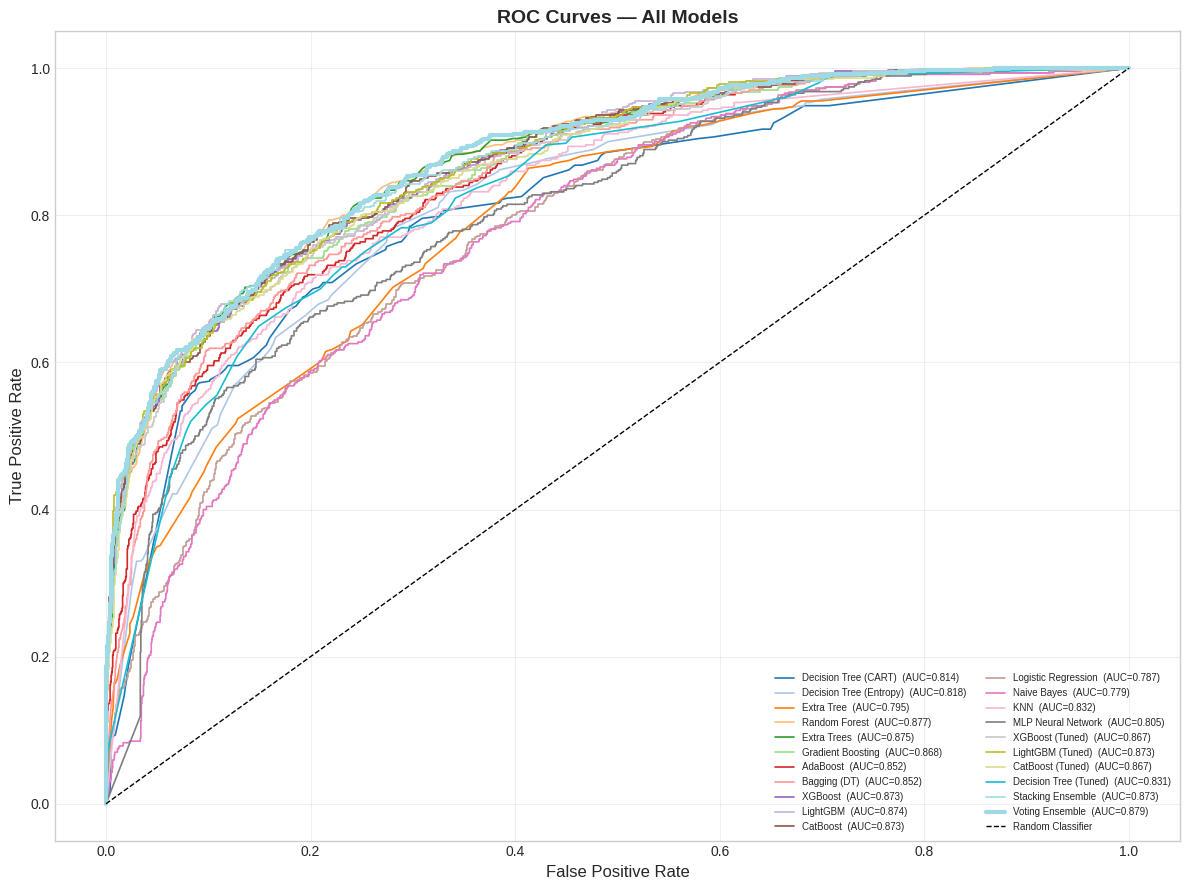

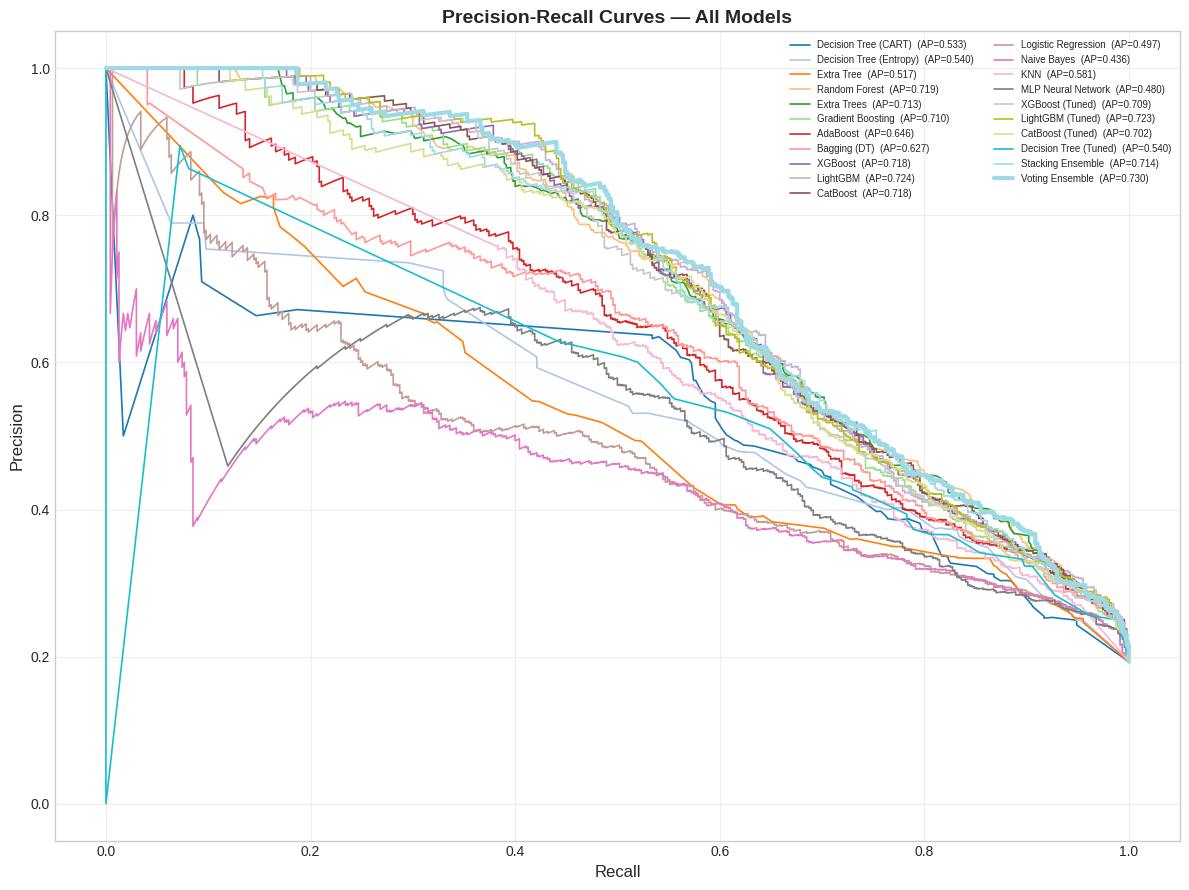

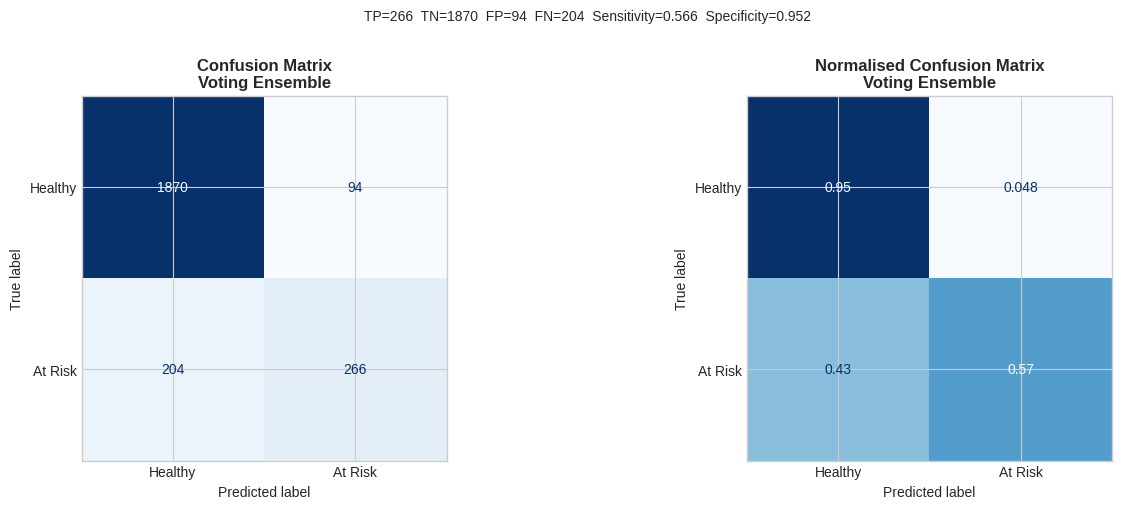


── Decision Tree (Tuned) — Top 4 Levels ─────────────────────────────────
|--- heart_disease <= 0.00
|   |--- ever_married <= -1.00
|   |   |--- prevalentStroke <= 0.00
|   |   |   |--- age_group_l <= 0.00
|   |   |   |   |--- chol <= -0.36
|   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |--- chol >  -0.36
|   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- age_group_l >  0.00
|   |   |   |   |--- age_group_l <= 1.00
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- age_group_l >  1.00
|   |   |   |   |   |--- truncated branch of depth 2
|   |   |--- prevalentStroke >  0.00
|   |   |   |--- prevalentStroke <= 0.14
|   |   |   |   |--- class: 1
|   |   |   |--- prevalentStroke >  0.14
|   |   |   |   |--- age <= 1.24
|   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |--- age >  1.24
|   |   |   |   |   |--- truncated branch of depth 2
|   |--- ever_married >  -1.00
|   |   |--- prevalentHyp <= -0.25
|   |   |   |--- sc <= -

In [11]:
# ──  Leaderboard (interactive) ───────────────────────────────────────
lb = pd.DataFrame(
    {n: {m: results[n][m] for m in ["accuracy","roc_auc","f1","mcc","bal_acc"]}
     for n in results}
).T.reset_index().rename(columns={"index":"Model",
                                    "accuracy":"Accuracy",
                                    "roc_auc":"ROC-AUC",
                                    "f1":"F1-Score",
                                    "mcc":"MCC",
                                    "bal_acc":"Balanced Acc"})
lb = lb.sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
lb.index = lb.index + 1
print("\n── MODEL LEADERBOARD ──────────────────────────────────────────")
print(lb[["Model","Accuracy","ROC-AUC","F1-Score","MCC","Balanced Acc"]].to_string())

fig = px.bar(lb.melt(id_vars="Model",
                      value_vars=["Accuracy","ROC-AUC","F1-Score","Balanced Acc"],
                      var_name="Metric", value_name="Score"),
             x="Score", y="Model", color="Metric", barmode="group",
             orientation="h",
             title="<b>All-Model Leaderboard — Multi-Metric</b>",
             color_discrete_sequence=["#2196F3","#4CAF50","#FF9800","#9C27B0"],
             height=700)
fig.update_layout(yaxis=dict(categoryorder="total ascending"),
                  xaxis_range=[0.6, 1.02])
fig.show()

# ──  ROC Curves ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 9))
colors  = plt.cm.tab20(np.linspace(0, 1, len(results)))

for (name, res), col in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res["proba"])
    lw = 3 if name == best_name else 1.2
    ax.plot(fpr, tpr, color=col, linewidth=lw,
            label=f"{name}  (AUC={res['roc_auc']:.3f})")

ax.plot([0,1],[0,1],"k--", linewidth=1, label="Random Classifier")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curves — All Models", fontsize=14, fontweight="bold")
ax.legend(loc="lower right", fontsize=7, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("eval_01_roc.png", dpi=150, bbox_inches="tight")
plt.show()

# ──  Precision-Recall ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 9))
for (name, res), col in zip(results.items(), colors):
    prec, rec, _ = precision_recall_curve(y_test, res["proba"])
    ap = average_precision_score(y_test, res["proba"])
    lw = 3 if name == best_name else 1.2
    ax.plot(rec, prec, color=col, linewidth=lw,
            label=f"{name}  (AP={ap:.3f})")
ax.set_xlabel("Recall", fontsize=12)
ax.set_ylabel("Precision", fontsize=12)
ax.set_title("Precision-Recall Curves — All Models", fontsize=14, fontweight="bold")
ax.legend(loc="upper right", fontsize=7, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("eval_02_pr.png", dpi=150, bbox_inches="tight")
plt.show()

# ──  Confusion Matrix — Best model ───────────────────────────────────
cm = confusion_matrix(y_test, results[best_name]["pred"])
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["Healthy", "At Risk"])
disp.plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title(f"Confusion Matrix\n{best_name}", fontweight="bold")

# Normalised
cmn = cm.astype(float) / cm.sum(axis=1, keepdims=True)
disp2 = ConfusionMatrixDisplay(confusion_matrix=np.round(cmn,3),
                                display_labels=["Healthy","At Risk"])
disp2.plot(ax=axes[1], cmap="Blues", colorbar=False)
axes[1].set_title(f"Normalised Confusion Matrix\n{best_name}", fontweight="bold")

plt.suptitle(f"TP={tp}  TN={tn}  FP={fp}  FN={fn}  "
             f"Sensitivity={tp/(tp+fn):.3f}  Specificity={tn/(tn+fp):.3f}",
             fontsize=10, y=1.01)
plt.tight_layout()
plt.savefig("eval_03_cm.png", dpi=150, bbox_inches="tight")
plt.show()

# ──  Decision Tree visualisation ─────────────────────────────────────
dt_name = "Decision Tree (Tuned)" if "Decision Tree (Tuned)" in trained_models \
          else "Decision Tree (CART)"
dt_mdl  = trained_models[dt_name]
tree_text = export_text(dt_mdl, feature_names=FEATURE_COLS, max_depth=4)
print(f"\n── {dt_name} — Top 4 Levels ─────────────────────────────────")
print(tree_text[:3000])   # first 3000 chars

# ──  Full Classification Report (Best) ────────────────────────────────
print(f"\n{'='*55}")
print(f"  CLASSIFICATION REPORT — {best_name}")
print(f"{'='*55}")
print(classification_report(y_test, results[best_name]["pred"],
                             target_names=["Healthy (0)", "At Risk (1)"]))

🌳 Comprehensive Decision Tree Analysis

⏳  Tuning Decision Tree depth (2 → 12) …
   Best depth = 8  (CV ROC-AUC = 0.9080 ± 0.0054)


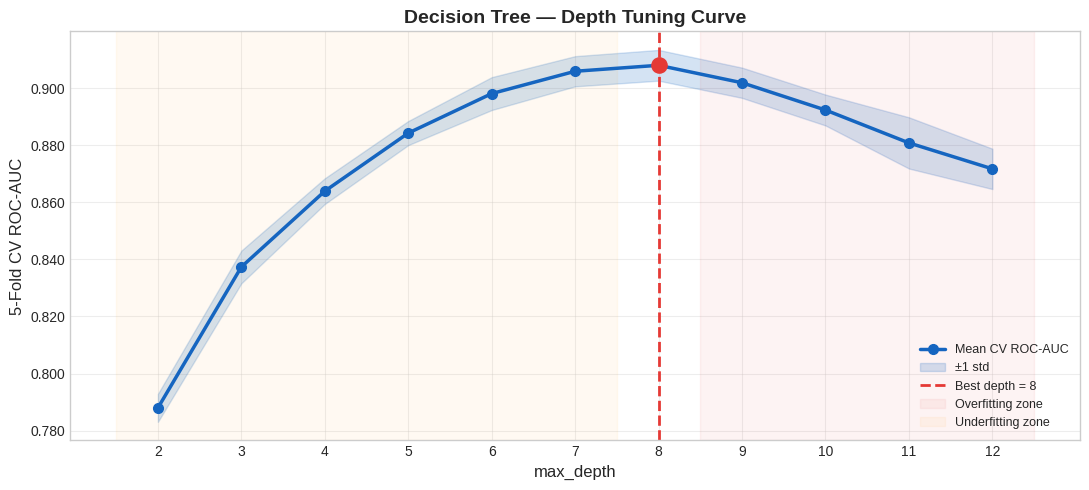

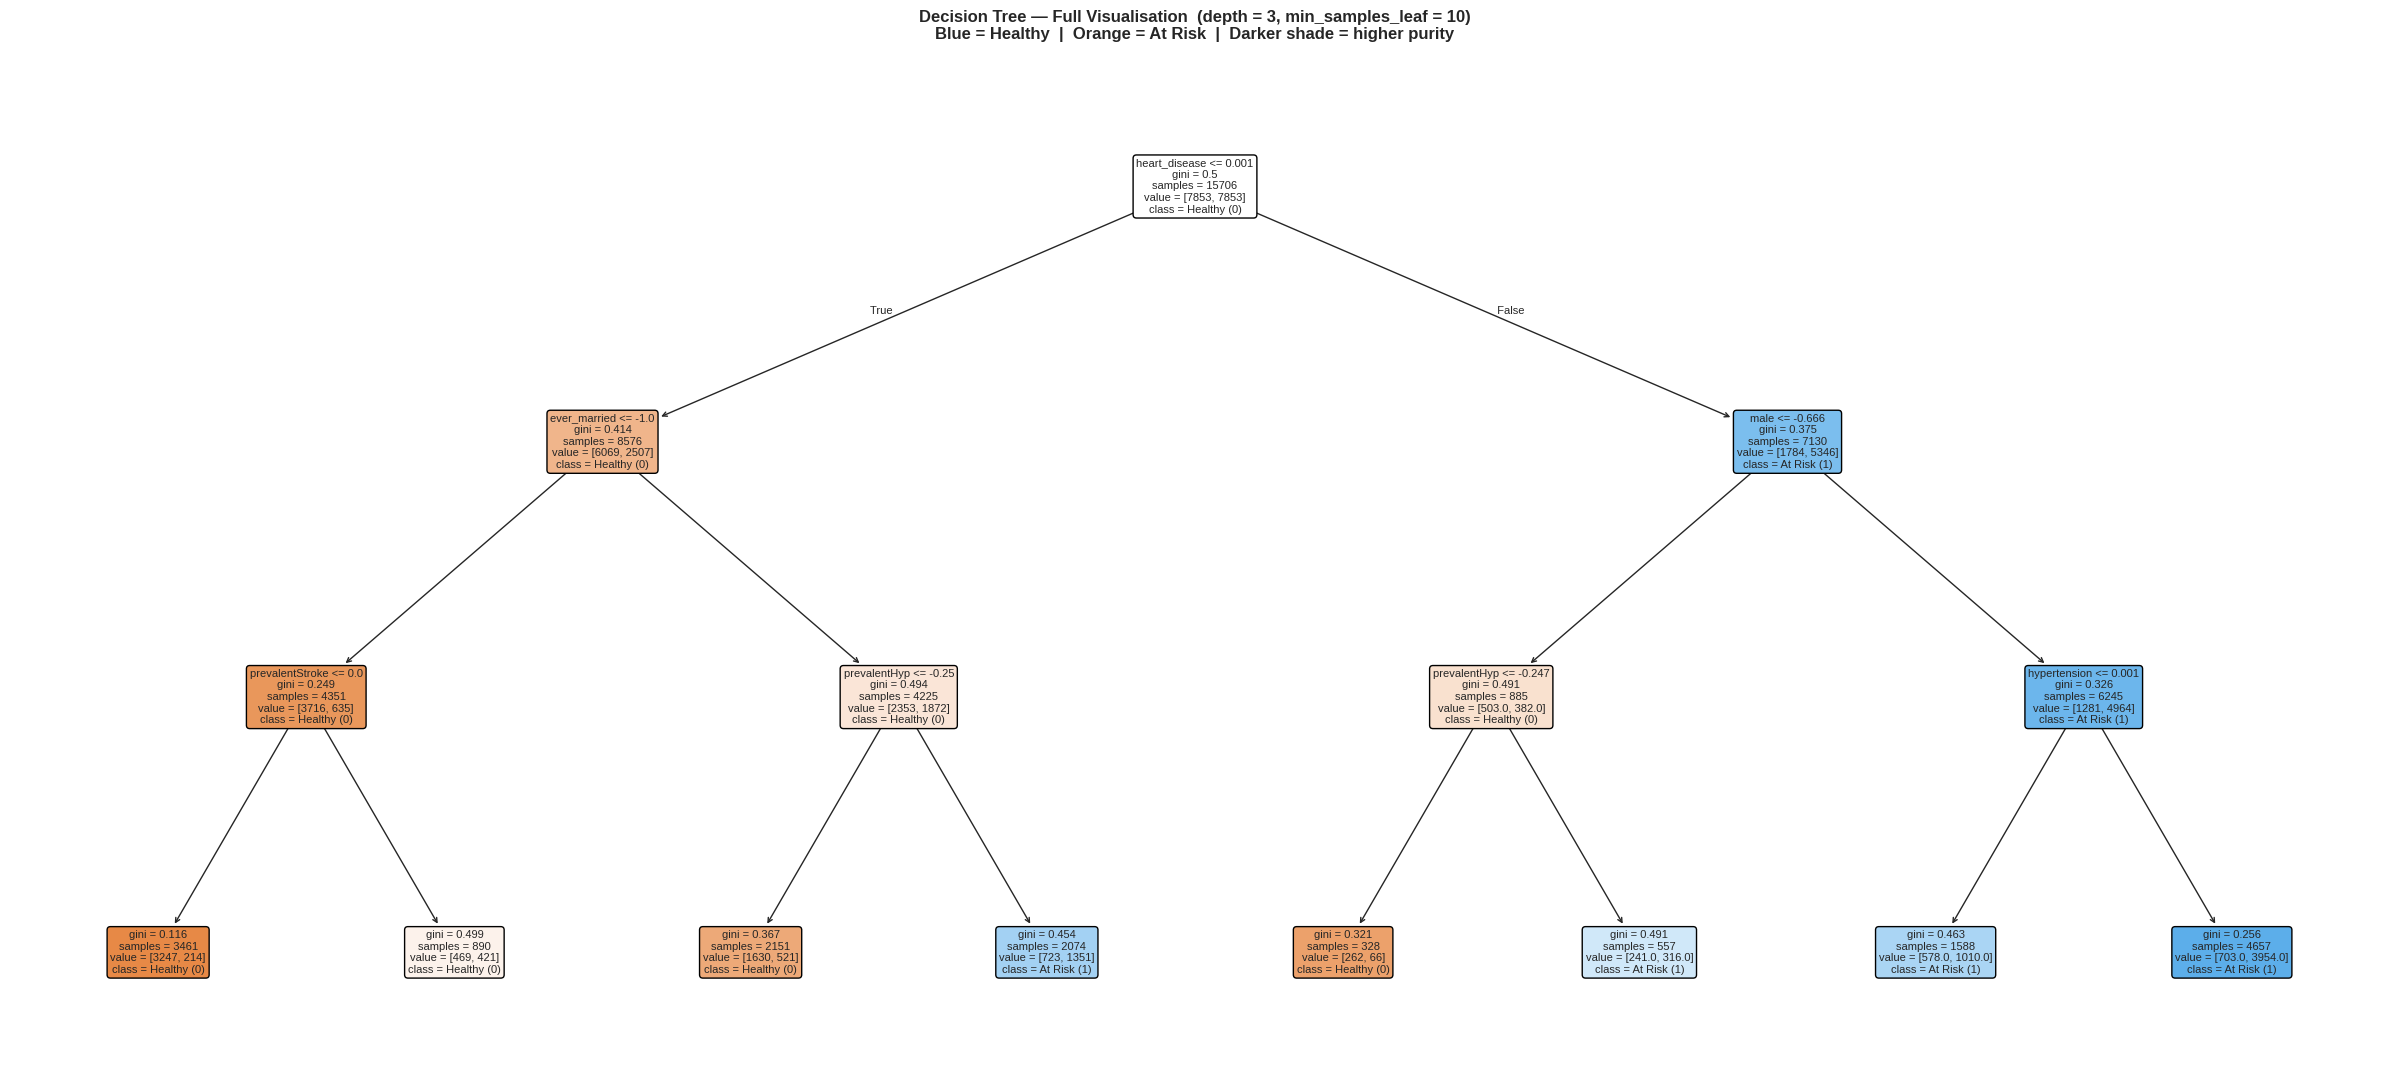

  Tree visualisation saved  →  dt_02_full_tree.png

⏳  Training per-disease Decision Trees (depth=8) …
  Breast Cancer                 AUC=0.884  Acc=0.904  F1=0.902  MCC=0.791
  Chronic Kidney Disease        AUC=0.923  Acc=0.912  F1=0.914  MCC=0.826
  Diabetes                      AUC=0.676  Acc=0.695  F1=0.698  MCC=0.345
  Heart Disease                 AUC=0.715  Acc=0.721  F1=0.719  MCC=0.436
  Hypertension / CHD            AUC=0.585  Acc=0.633  F1=0.683  MCC=0.133
  Liver Disease                 AUC=0.654  Acc=0.658  F1=0.674  MCC=0.329
  Parkinson's Disease           AUC=0.879  Acc=0.872  F1=0.877  MCC=0.706
  Stroke                        AUC=0.765  Acc=0.879  F1=0.898  MCC=0.149


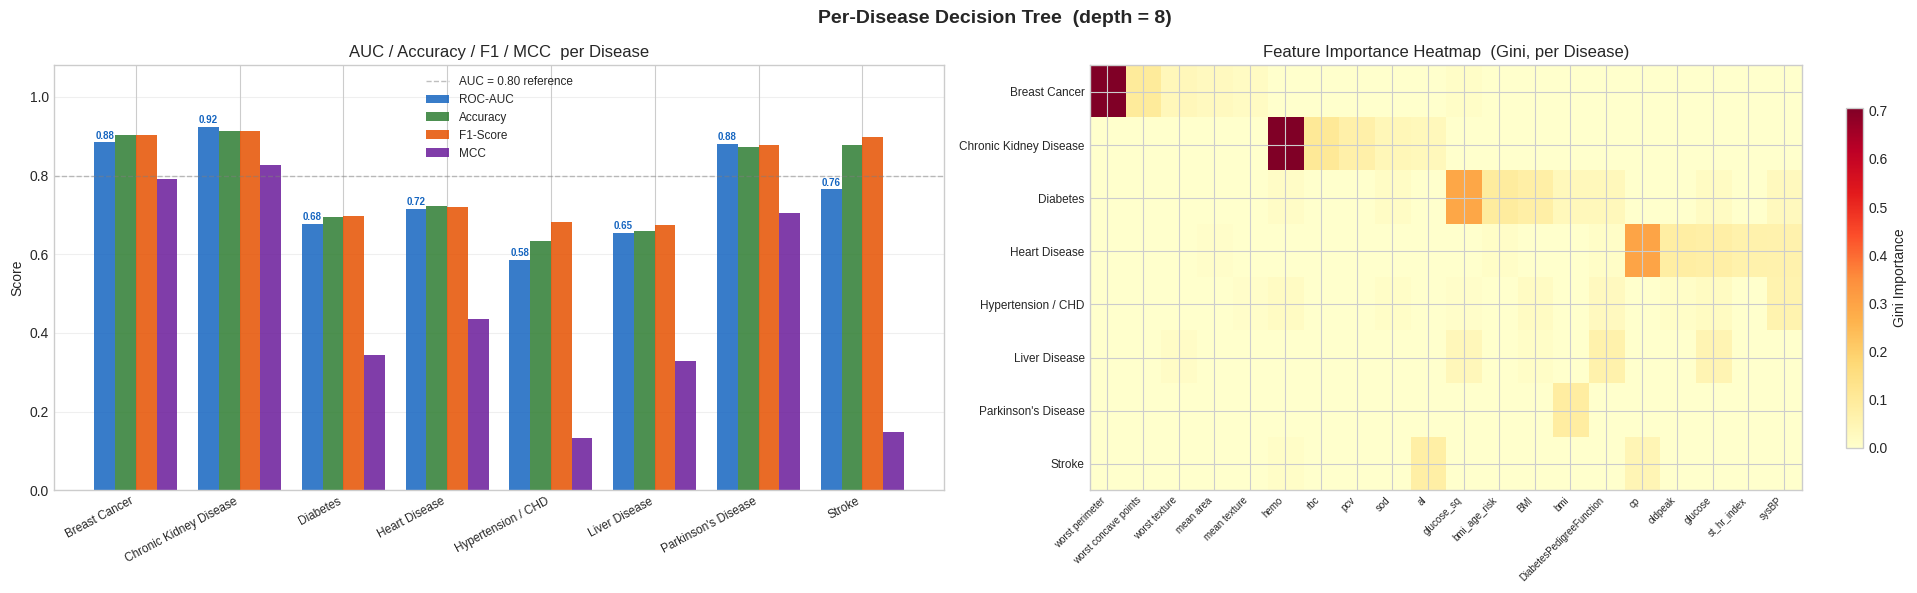

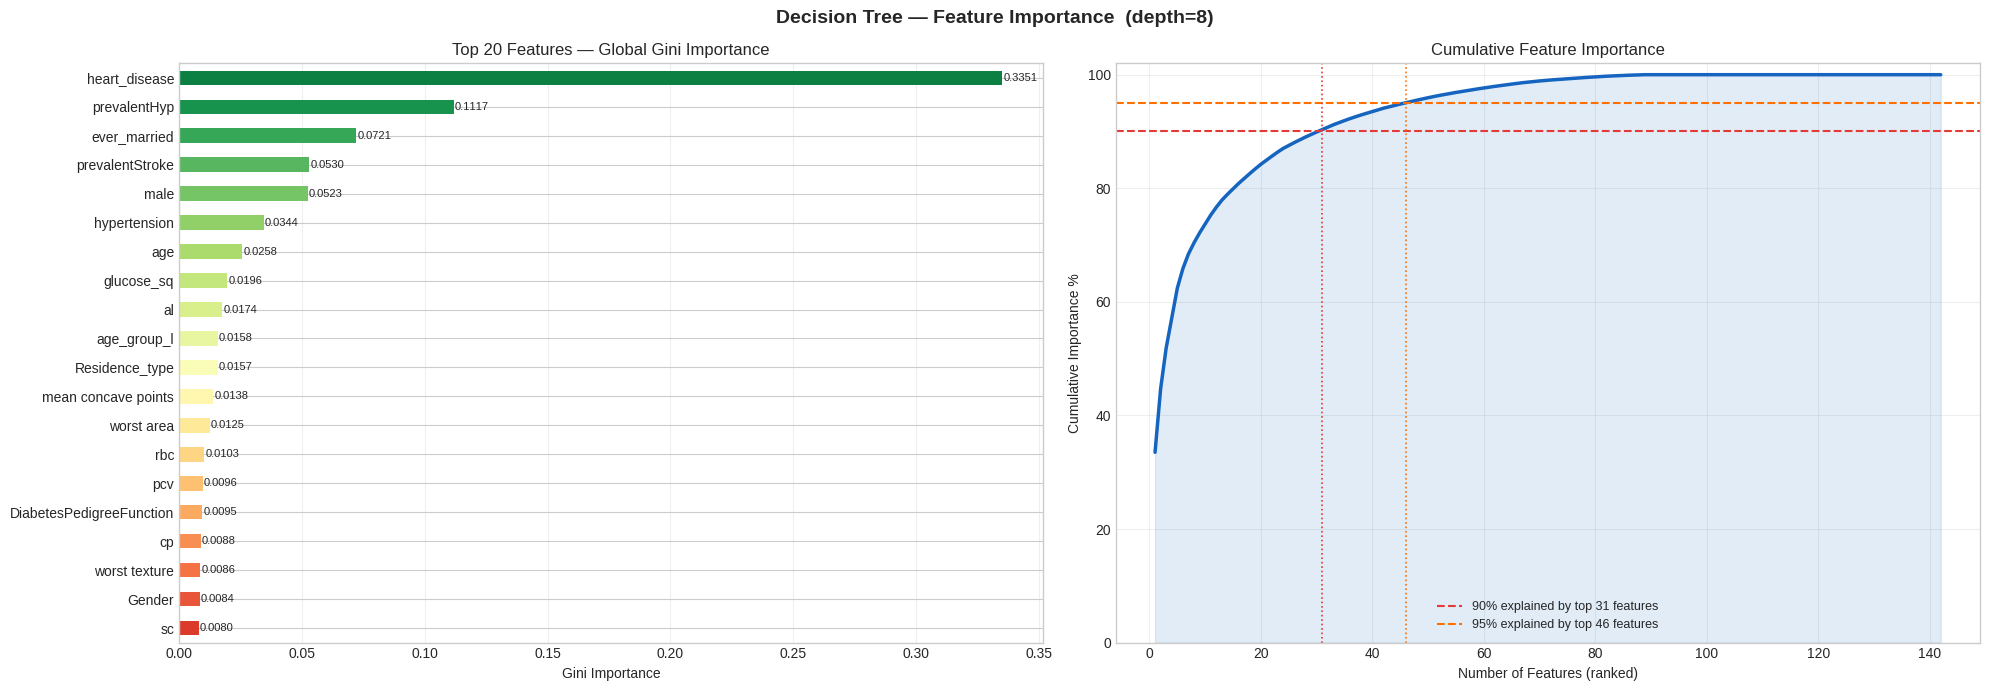

   Top 20 features explain 84.2% of total importance
   31 features needed for 90% coverage
   46 features needed for 95% coverage

╔══════════════════════════════════════════════════════════════════╗
║          DECISION PATH TRACE — High-Risk Test Patient #7         ║
╠══════════════════════════════════════════════════════════════════╣
║  Step 1 │ Node   0 │ heart_disease                =   4.0000      ║
║         │         │ Threshold   0.0009  → ↘ RIGHT → higher risk   ║
║  ───────────────────────────────────────────────────────────────  ║
║  Step 2 │ Node 164 │ male                         =   0.3333      ║
║         │         │ Threshold  -0.6661  → ↘ RIGHT → higher risk   ║
║  ───────────────────────────────────────────────────────────────  ║
║  Step 3 │ Node 218 │ hypertension                 =   0.5000      ║
║         │         │ Threshold   0.0007  → ↘ RIGHT → higher risk   ║
║  ───────────────────────────────────────────────────────────────  ║
║  Step 4 │ Node 272 │ glucose_

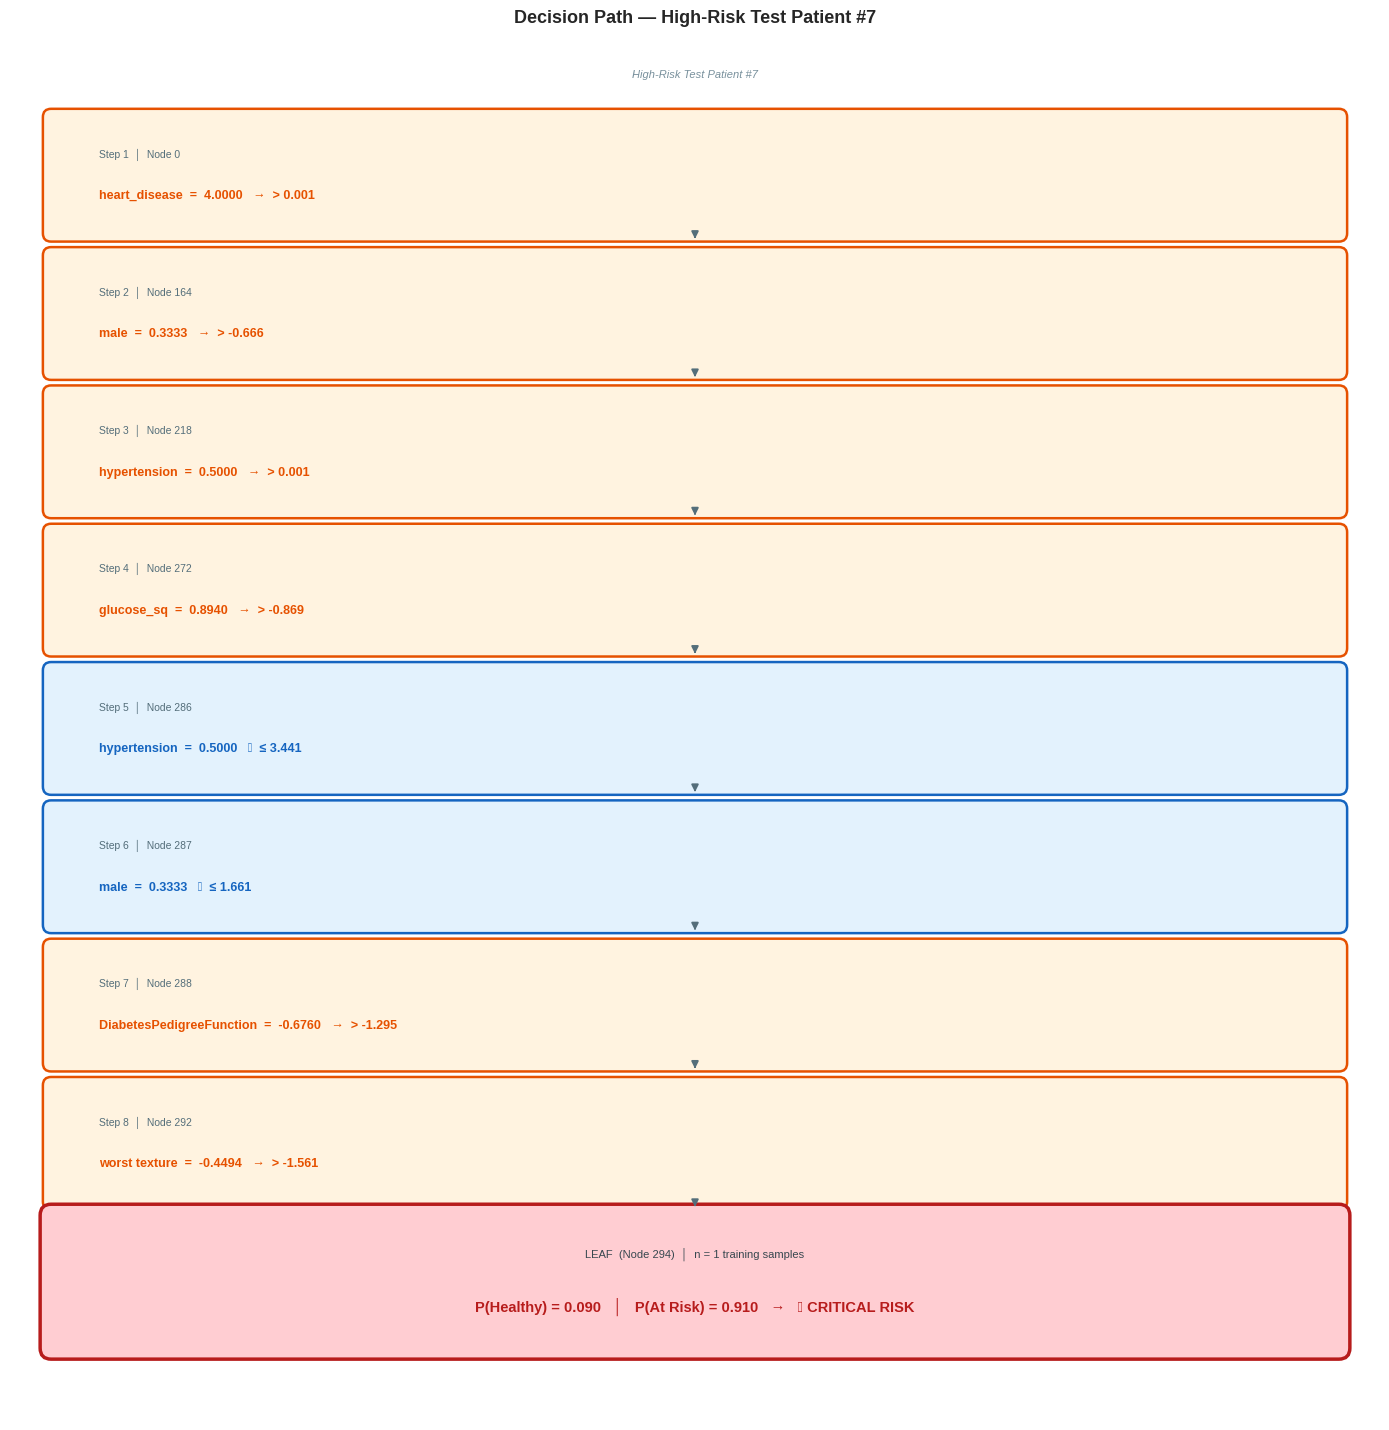

  Path diagram saved → dt_05_decision_path.png

  DECISION TREE — HUMAN-READABLE RULES  (depth = 4)
  (These are the exact if-then-else paths the model uses)
|--- heart_disease <= 0.00
|   |--- ever_married <= -1.00
|   |   |--- prevalentStroke <= 0.00
|   |   |   |--- age_group_l <= 0.00
|   |   |   |   |--- class: 0
|   |   |   |--- age_group_l >  0.00
|   |   |   |   |--- class: 0
|   |   |--- prevalentStroke >  0.00
|   |   |   |--- prevalentStroke <= 0.14
|   |   |   |   |--- class: 1
|   |   |   |--- prevalentStroke >  0.14
|   |   |   |   |--- class: 0
|   |--- ever_married >  -1.00
|   |   |--- prevalentHyp <= -0.25
|   |   |   |--- sc <= -0.27
|   |   |   |   |--- class: 0
|   |   |   |--- sc >  -0.27
|   |   |   |   |--- class: 0
|   |   |--- prevalentHyp >  -0.25
|   |   |   |--- prevalentHyp <= 1.50
|   |   |   |   |--- class: 1
|   |   |   |--- prevalentHyp >  1.50
|   |   |   |   |--- class: 0
|--- heart_disease >  0.00
|   |--- male <= -0.67
|   |   |--- prevalentHyp <= 

In [12]:

# ┌─────────────────────────────────────────────────────────────────────────┐
# │  Comprehensive Decision Tree Analysis                                   │
# │                                                                         │
# │  What this produces:                                                    │
# │     Depth tuning curve  (CV AUC vs max_depth 2–12)                      │
# │     Full tree visualisation  (depth-3 interpretable)                    │
# │     Per-disease DT trained separately + grouped bar chart               │
# │     Global Gini feature importance bar chart                            │
# │     Decision path trace  (sample patient, text + visual)                │
# │     Printed human-readable rule text  (depth 4)                         │
# └─────────────────────────────────────────────────────────────────────────┘


import matplotlib.pyplot    as plt
import matplotlib.patches   as mpatches
from matplotlib.patches     import FancyBboxPatch
import matplotlib.gridspec  as gridspec
import numpy  as np
import pandas as pd

from sklearn.tree            import (DecisionTreeClassifier, export_text,
                                      plot_tree)
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics         import (roc_auc_score, accuracy_score,
                                      f1_score, balanced_accuracy_score,
                                      matthews_corrcoef)

plt.style.use("seaborn-v0_8-whitegrid")
CV_SCORER_DT = StratifiedKFold(CV_FOLDS, shuffle=True, random_state=SEED)


#  11b-1  DEPTH TUNING CURVE
#         Find the sweet spot between under- and over-fitting
print("⏳  Tuning Decision Tree depth (2 → 12) …")
DEPTHS      = range(2, 13)
depth_mean  = []
depth_std   = []

for d in DEPTHS:
    dt_tmp = DecisionTreeClassifier(
        max_depth=d, class_weight="balanced",
        criterion="gini", random_state=SEED)
    sc = cross_val_score(
        dt_tmp, X_train_bal, y_train_bal,
        cv=CV_SCORER_DT, scoring="roc_auc", n_jobs=-1)
    depth_mean.append(sc.mean())
    depth_std.append(sc.std())

depth_mean = np.array(depth_mean)
depth_std  = np.array(depth_std)
best_depth = list(DEPTHS)[np.argmax(depth_mean)]
print(f"   Best depth = {best_depth}  "
      f"(CV ROC-AUC = {depth_mean.max():.4f} ± {depth_std[np.argmax(depth_mean)]:.4f})")

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(list(DEPTHS), depth_mean, "o-", color="#1565C0", lw=2.5, ms=7,
        label="Mean CV ROC-AUC")
ax.fill_between(list(DEPTHS),
                depth_mean - depth_std,
                depth_mean + depth_std,
                alpha=0.18, color="#1565C0", label="±1 std")
ax.axvline(best_depth, ls="--", color="#E53935", lw=2,
           label=f"Best depth = {best_depth}")
ax.scatter([best_depth], [depth_mean.max()],
           color="#E53935", s=120, zorder=5)

# Shade overfitting zone
ax.axvspan(best_depth + 0.5, list(DEPTHS)[-1] + 0.5,
           alpha=0.06, color="#E53935", label="Overfitting zone")
ax.axvspan(list(DEPTHS)[0] - 0.5, best_depth - 0.5,
           alpha=0.06, color="#FFA726", label="Underfitting zone")

ax.set_xlabel("max_depth", fontsize=12)
ax.set_ylabel("5-Fold CV ROC-AUC", fontsize=12)
ax.set_title("Decision Tree — Depth Tuning Curve",
             fontsize=14, fontweight="bold")
ax.set_xticks(list(DEPTHS))
ax.legend(fontsize=9, loc="lower right")
ax.yaxis.set_major_formatter(plt.FormatStrFormatter("%.3f"))
ax.grid(True, alpha=0.35)
plt.tight_layout()
plt.savefig("dt_01_depth_tuning.png", dpi=150, bbox_inches="tight")
plt.show()


#  11b-2  FULL TREE VISUALISATION (depth = 3 for readability)
#         Train a dedicated shallow tree — interpretable by clinicians
DT_DISPLAY_DEPTH = 3   # fixed for visualisation clarity

dt_display = DecisionTreeClassifier(
    max_depth=DT_DISPLAY_DEPTH, class_weight="balanced",
    criterion="gini", min_samples_leaf=10, random_state=SEED)
dt_display.fit(X_train_bal, y_train_bal)

fig, ax = plt.subplots(figsize=(24, 11))
plot_tree(
    dt_display,
    feature_names  = FEATURE_COLS,
    class_names    = ["Healthy (0)", "At Risk (1)"],
    filled         = True,
    rounded        = True,
    impurity       = True,
    proportion     = False,
    fontsize       = 8,
    ax             = ax,
    precision      = 3,
)
ax.set_title(
    f"Decision Tree — Full Visualisation  (depth = {DT_DISPLAY_DEPTH}, "
    f"min_samples_leaf = 10)\n"
    f"Blue = Healthy  |  Orange = At Risk  |  "
    f"Darker shade = higher purity",
    fontsize=12, fontweight="bold", pad=14)
plt.tight_layout()
plt.savefig("dt_02_full_tree.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"  Tree visualisation saved  →  dt_02_full_tree.png")


#  11b-3  PER-DISEASE DECISION TREE
#         Train one DT per disease on its own data → individual AUC / F1
print(f"\n⏳  Training per-disease Decision Trees (depth={best_depth}) …")

# Attach disease labels to test index so we can filter
X_test_meta_dt = X_test_raw.copy()            # original unscaled, has correct index
X_test_meta_dt["__disease__"] = df.loc[X_test_raw.index, "disease"].values
X_test_meta_dt["__target__"]  = y_test

disease_dt_results = {}

for disease in sorted(df["disease"].unique()):
    # Select rows for this disease from the ORIGINAL combined df
    mask  = df["disease"] == disease
    X_d   = df.loc[mask, FEATURE_COLS].copy()
    y_d   = df.loc[mask, "target"].values

    if len(np.unique(y_d)) < 2 or len(y_d) < 40:
        print(f"  ⚠️  {disease}: skipped (too few samples or single class)")
        continue

    # Scale with the global scaler (already fit in Cell 7)
    X_d_s = scaler.transform(X_d)

    # 80/20 split per disease
    from sklearn.model_selection import train_test_split as _tts
    Xtr, Xte, ytr, yte = _tts(X_d_s, y_d, test_size=0.20,
                                random_state=SEED, stratify=y_d)

    # SMOTE only if minority < 10%
    if ytr.mean() < 0.10 or ytr.mean() > 0.90:
        from imblearn.over_sampling import SMOTE as _SMOTE
        try:
            Xtr, ytr = _SMOTE(random_state=SEED, k_neighbors=3).fit_resample(Xtr, ytr)
        except Exception:
            pass

    dt_d = DecisionTreeClassifier(
        max_depth=best_depth, class_weight="balanced",
        criterion="gini", random_state=SEED)
    dt_d.fit(Xtr, ytr)

    yp_d   = dt_d.predict(Xte)
    ypr_d  = dt_d.predict_proba(Xte)[:, 1]

    disease_dt_results[disease] = {
        "model"   : dt_d,
        "auc"     : roc_auc_score(yte, ypr_d) if len(np.unique(yte)) > 1 else 0.5,
        "acc"     : accuracy_score(yte, yp_d),
        "f1"      : f1_score(yte, yp_d, average="weighted"),
        "mcc"     : matthews_corrcoef(yte, yp_d),
        "bal_acc" : balanced_accuracy_score(yte, yp_d),
        "n_train" : len(Xtr),
        "n_test"  : len(Xte),
        "features": FEATURE_COLS,
        "top_feat": pd.Series(dt_d.feature_importances_,
                               index=FEATURE_COLS).nlargest(5).index.tolist(),
    }
    r = disease_dt_results[disease]
    print(f"  {disease:<28}  AUC={r['auc']:.3f}  Acc={r['acc']:.3f}  "
          f"F1={r['f1']:.3f}  MCC={r['mcc']:.3f}")

# ── Grouped bar chart ─────────────────────────────────────────────────────
dnames = list(disease_dt_results.keys())
aucs   = [disease_dt_results[d]["auc"]     for d in dnames]
accs   = [disease_dt_results[d]["acc"]     for d in dnames]
f1s    = [disease_dt_results[d]["f1"]      for d in dnames]
mccs   = [disease_dt_results[d]["mcc"]     for d in dnames]

x_pos  = np.arange(len(dnames))
W      = 0.20

fig, axes = plt.subplots(1, 2, figsize=(20, 6))
fig.suptitle(f"Per-Disease Decision Tree  (depth = {best_depth})",
             fontsize=14, fontweight="bold")

# Left: metric bars
PALETTE = ["#1565C0", "#2E7D32", "#E65100", "#6A1B9A"]
for i, (metric, vals, label) in enumerate(
        zip(["AUC","Acc","F1","MCC"],
            [aucs, accs, f1s, mccs],
            ["ROC-AUC","Accuracy","F1-Score","MCC"])):
    axes[0].bar(x_pos + (i - 1.5)*W, vals, W,
                label=label, color=PALETTE[i], alpha=0.85)

axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(dnames, rotation=28, ha="right", fontsize=8.5)
axes[0].set_ylabel("Score")
axes[0].set_ylim(0, 1.08)
axes[0].axhline(0.8, ls="--", color="grey", lw=1, alpha=0.5,
                label="AUC = 0.80 reference")
axes[0].legend(fontsize=8.5)
axes[0].set_title("AUC / Accuracy / F1 / MCC  per Disease")
axes[0].grid(axis="y", alpha=0.3)

# Add value labels on AUC bars
for i, (xi, v) in enumerate(zip(x_pos - 1.5*W, aucs)):
    axes[0].text(xi, v + 0.01, f"{v:.2f}", ha="center",
                 fontsize=7, fontweight="bold", color="#1565C0")

# Right: top feature per disease heatmap-style
all_top_feats = []
for d in dnames:
    all_top_feats.extend(disease_dt_results[d]["top_feat"])
uniq_feats = list(dict.fromkeys(all_top_feats))[:20]   # preserve order, cap at 20

heat_data = np.zeros((len(dnames), len(uniq_feats)))
for i, d in enumerate(dnames):
    imp = pd.Series(
        disease_dt_results[d]["model"].feature_importances_,
        index=FEATURE_COLS)
    for j, f in enumerate(uniq_feats):
        if f in imp.index:
            heat_data[i, j] = imp[f]

im = axes[1].imshow(heat_data, aspect="auto", cmap="YlOrRd",
                     interpolation="nearest")
axes[1].set_xticks(range(len(uniq_feats)))
axes[1].set_xticklabels(uniq_feats, rotation=45, ha="right", fontsize=7)
axes[1].set_yticks(range(len(dnames)))
axes[1].set_yticklabels(dnames, fontsize=8.5)
axes[1].set_title("Feature Importance Heatmap  (Gini, per Disease)")
plt.colorbar(im, ax=axes[1], shrink=0.8, label="Gini Importance")

plt.tight_layout()
plt.savefig("dt_03_per_disease.png", dpi=150, bbox_inches="tight")
plt.show()


#  11b-4  GLOBAL GINI FEATURE IMPORTANCE
#         Uses the BEST-DEPTH DT trained on the full balanced dataset
dt_best = DecisionTreeClassifier(
    max_depth=best_depth, class_weight="balanced",
    criterion="gini", random_state=SEED)
dt_best.fit(X_train_bal, y_train_bal)

importances = (pd.Series(dt_best.feature_importances_, index=FEATURE_COLS)
               .sort_values(ascending=False))
top_n = importances.head(20)

fig, axes = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle(f"Decision Tree — Feature Importance  (depth={best_depth})",
             fontsize=14, fontweight="bold")

# Left: bar chart
colors_imp = plt.cm.RdYlGn_r(np.linspace(0.05, 0.88, len(top_n)))
top_n[::-1].plot(kind="barh", ax=axes[0], color=colors_imp[::-1])
axes[0].set_title("Top 20 Features — Global Gini Importance")
axes[0].set_xlabel("Gini Importance")
for i, v in enumerate(top_n.values[::-1]):
    axes[0].text(v + 0.0005, i, f"{v:.4f}", va="center", fontsize=8)
axes[0].grid(axis="x", alpha=0.3)

# Right: cumulative importance
cumulative = importances.values.cumsum() / importances.values.sum() * 100
n_to_90    = int(np.searchsorted(cumulative, 90)) + 1
n_to_95    = int(np.searchsorted(cumulative, 95)) + 1

axes[1].plot(range(1, len(cumulative) + 1), cumulative,
             color="#1565C0", lw=2.5)
axes[1].fill_between(range(1, len(cumulative) + 1), cumulative,
                      alpha=0.12, color="#1565C0")
axes[1].axhline(90, ls="--", color="#E53935", lw=1.5,
                label=f"90% explained by top {n_to_90} features")
axes[1].axhline(95, ls="--", color="#FF6F00", lw=1.5,
                label=f"95% explained by top {n_to_95} features")
axes[1].axvline(n_to_90, ls=":", color="#E53935", lw=1.2)
axes[1].axvline(n_to_95, ls=":", color="#FF6F00", lw=1.2)
axes[1].set_xlabel("Number of Features (ranked)")
axes[1].set_ylabel("Cumulative Importance %")
axes[1].set_title("Cumulative Feature Importance")
axes[1].set_ylim(0, 102)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("dt_04_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"   Top 20 features explain "
      f"{top_n.sum()/importances.sum()*100:.1f}% of total importance")
print(f"   {n_to_90} features needed for 90% coverage")
print(f"   {n_to_95} features needed for 95% coverage")


#  11b-5  DECISION PATH VISUAL — trace a high-risk patient step-by-step
def trace_decision_path(model, sample_scaled, feature_names,
                         patient_label="Sample Patient"):
    """
    Print and visualise the exact node-by-node path through the tree
    for a single patient.
    """
    tree_           = model.tree_
    node_indicator  = model.decision_path(sample_scaled)
    leaf_id         = model.apply(sample_scaled)[0]
    node_ids        = node_indicator.indices[
                          node_indicator.indptr[0]:node_indicator.indptr[1]]

    path_records = []
    for nid in node_ids:
        if tree_.feature[nid] != -2:          # internal node
            feat      = feature_names[tree_.feature[nid]]
            threshold = tree_.threshold[nid]
            val       = float(sample_scaled[0, tree_.feature[nid]])
            went_left = val <= threshold
            n_healthy = tree_.value[nid][0][0]
            n_atrisk  = tree_.value[nid][0][1] if tree_.n_classes[0] > 1 else 0
            path_records.append({
                "node"     : nid,
                "type"     : "decision",
                "feature"  : feat,
                "threshold": threshold,
                "value"    : val,
                "direction": f"{'≤' if went_left else '>'} {threshold:.3f}",
                "branch"   : "LEFT  → lower risk" if went_left else "RIGHT → higher risk",
                "n_healthy": int(n_healthy),
                "n_atrisk" : int(n_atrisk),
            })
        else:                                   # leaf
            n_vals  = tree_.value[nid][0]
            probs   = n_vals / n_vals.sum()
            path_records.append({
                "node"       : nid,
                "type"       : "leaf",
                "prob_healthy": probs[0],
                "prob_atrisk" : probs[1] if len(probs) > 1 else 1 - probs[0],
                "n_samples"  : int(n_vals.sum()),
            })

    # ── Print report ─────────────────────────────────────────────────────
    w = 68
    print("\n" + "╔" + "═"*(w-2) + "╗")
    print("║" + f"  DECISION PATH TRACE — {patient_label}".center(w-2) + "║")
    print("╠" + "═"*(w-2) + "╣")

    for step, rec in enumerate(path_records):
        if rec["type"] == "decision":
            arrow = "↓" if rec["branch"].startswith("LEFT") else "↘"
            line1 = (f"  Step {step+1} │ Node {rec['node']:>3} │ "
                     f"{rec['feature'][:28]:<28} = {rec['value']:>8.4f}")
            line2 = (f"         │         │ Threshold {rec['threshold']:>8.4f}  "
                     f"→ {arrow} {rec['branch']}")
            print("║" + line1.ljust(w-1) + "║")
            print("║" + line2.ljust(w-1) + "║")
            print("║" + ("  " + "─"*(w-5)).ljust(w-1) + "║")
        else:
            prob = rec["prob_atrisk"]
            risk_label = (
                "🟢 LOW RISK"      if prob < 0.25 else
                "🟡 MODERATE RISK" if prob < 0.50 else
                "🟠 HIGH RISK"     if prob < 0.75 else
                "🔴 CRITICAL RISK")
            print("║" + (f"  LEAF  │ Node {rec['node']:>3} │ "
                          f"Samples in leaf = {rec['n_samples']}").ljust(w-1) + "║")
            print("║" + (f"         │         │ P(Healthy)  = "
                          f"{rec['prob_healthy']:.3f}").ljust(w-1) + "║")
            print("║" + (f"         │         │ P(At Risk)  = "
                          f"{prob:.3f}  → {risk_label}").ljust(w-1) + "║")
    print("╚" + "═"*(w-2) + "╝")

    # ── Visual path diagram ───────────────────────────────────────────────
    n_steps = len(path_records)
    fig, ax = plt.subplots(figsize=(14, max(5, n_steps * 1.6)))
    ax.set_xlim(0, 10); ax.set_ylim(-0.5, n_steps + 0.5)
    ax.axis("off")
    ax.set_title(f"Decision Path — {patient_label}",
                 fontsize=13, fontweight="bold", pad=10)

    COLORS = {"decision_left"  : "#E3F2FD",
              "decision_right" : "#FFF3E0",
              "leaf_low"       : "#C8E6C9",
              "leaf_moderate"  : "#FFF9C4",
              "leaf_high"      : "#FFE0B2",
              "leaf_critical"  : "#FFCDD2"}
    BORDER  = {"decision_left" : "#1565C0", "decision_right": "#E65100",
                "leaf_low"     : "#2E7D32", "leaf_moderate" : "#F57F17",
                "leaf_high"    : "#E65100", "leaf_critical" : "#B71C1C"}

    for i, rec in enumerate(path_records):
        y_pos = n_steps - i - 0.5
        if rec["type"] == "decision":
            went_left = rec["branch"].startswith("LEFT")
            ckey = "decision_left" if went_left else "decision_right"
            icon = "✓" if went_left else "→"
            box  = FancyBboxPatch((0.3, y_pos - 0.42), 9.4, 0.84,
                                   boxstyle="round,pad=0.06",
                                   fc=COLORS[ckey], ec=BORDER[ckey], lw=1.8)
            ax.add_patch(box)
            ax.text(0.65, y_pos + 0.15,
                    f"Step {i+1}  │  Node {rec['node']}",
                    fontsize=7.5, color="#546E7A", va="center")
            ax.text(0.65, y_pos - 0.15,
                    f"{rec['feature'][:32]}  =  {rec['value']:.4f}   "
                    f"{icon}  {rec['direction']}",
                    fontsize=9, fontweight="bold", va="center",
                    color=BORDER[ckey])
            # Arrow down
            if i < n_steps - 1:
                ax.annotate("", xy=(5, y_pos - 0.48),
                            xytext=(5, y_pos - 0.42),
                            arrowprops=dict(arrowstyle="-|>", color="#546E7A",
                                            lw=1.4))
        else:
            prob = rec["prob_atrisk"]
            if prob < 0.25:   ckey = "leaf_low"
            elif prob < 0.50: ckey = "leaf_moderate"
            elif prob < 0.75: ckey = "leaf_high"
            else:             ckey = "leaf_critical"

            risk_lbl = (
                "🟢 LOW RISK"      if prob < 0.25 else
                "🟡 MODERATE RISK" if prob < 0.50 else
                "🟠 HIGH RISK"     if prob < 0.75 else
                "🔴 CRITICAL RISK")

            box = FancyBboxPatch((0.3, y_pos - 0.48), 9.4, 0.96,
                                  boxstyle="round,pad=0.08",
                                  fc=COLORS[ckey], ec=BORDER[ckey], lw=2.5)
            ax.add_patch(box)
            ax.text(5, y_pos + 0.20,
                    f"LEAF  (Node {rec['node']})  │  "
                    f"n = {rec['n_samples']} training samples",
                    fontsize=8, ha="center", va="center", color="#37474F")
            ax.text(5, y_pos - 0.18,
                    f"P(Healthy) = {rec['prob_healthy']:.3f}   │   "
                    f"P(At Risk) = {prob:.3f}   →   {risk_lbl}",
                    fontsize=10.5, fontweight="bold", ha="center", va="center",
                    color=BORDER[ckey])

    ax.text(5, n_steps + 0.2, patient_label,
            fontsize=8, ha="center", style="italic", color="#78909C")

    plt.tight_layout()
    outname = f"dt_05_decision_path.png"
    plt.savefig(outname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Path diagram saved → {outname}")
    return path_records


# Find a high-risk patient in the test set for a compelling demo
risk_proba   = dt_best.predict_proba(X_test_s)[:, 1]
high_risk_idx = np.where((risk_proba > 0.65) & (y_test == 1))[0]
if len(high_risk_idx) == 0:
    high_risk_idx = np.where(risk_proba > 0.50)[0]
demo_idx = high_risk_idx[0] if len(high_risk_idx) > 0 else 0

sample_scaled = X_test_s[demo_idx:demo_idx+1]
_ = trace_decision_path(dt_best, sample_scaled, FEATURE_COLS,
                         patient_label=f"High-Risk Test Patient #{demo_idx}")



#  11b-6  HUMAN-READABLE RULE TEXT  (depth 4)
dt_rules = DecisionTreeClassifier(
    max_depth=4, class_weight="balanced",
    criterion="gini", min_samples_leaf=15, random_state=SEED)
dt_rules.fit(X_train_bal, y_train_bal)
rule_text = export_text(dt_rules, feature_names=FEATURE_COLS, max_depth=4)

print(f"\n{'='*68}")
print(f"  DECISION TREE — HUMAN-READABLE RULES  (depth = 4)")
print(f"  (These are the exact if-then-else paths the model uses)")
print(f"{'='*68}")
print(rule_text[:4000])    # cap output; full tree can be very long
if len(rule_text) > 4000:
    print("  … (truncated — reduce max_depth for full view) …")

# ── Quick performance summary for the best-depth DT ──────────────────────
y_pred_dt  = dt_best.predict(X_test_s)
y_proba_dt = dt_best.predict_proba(X_test_s)[:, 1]
print(f"\n{'='*68}")
print(f"  DECISION TREE SUMMARY  (depth = {best_depth})")
print(f"{'='*68}")
print(f"  ROC-AUC        : {roc_auc_score(y_test, y_proba_dt):.4f}")
print(f"  Accuracy       : {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"  F1-Score       : {f1_score(y_test, y_pred_dt, average='weighted'):.4f}")
print(f"  MCC            : {matthews_corrcoef(y_test, y_pred_dt):.4f}")
print(f"  Balanced Acc   : {balanced_accuracy_score(y_test, y_pred_dt):.4f}")
print(f"  Total nodes    : {dt_best.tree_.node_count}")
print(f"  Leaves         : {dt_best.tree_.n_leaves}")
print(f"  Top feature    : {FEATURE_COLS[dt_best.tree_.feature[0]]}")
print(f"{'='*68}")
print("\n  Cell complete — 5 plots saved:")
for f in ["dt_01_depth_tuning.png","dt_02_full_tree.png",
          "dt_03_per_disease.png","dt_04_feature_importance.png",
          "dt_05_decision_path.png"]:
    print(f"   • {f}")


🔎 SHAP Explainability (Explainable AI)

  Computing SHAP — using XGBoost (Tuned) …


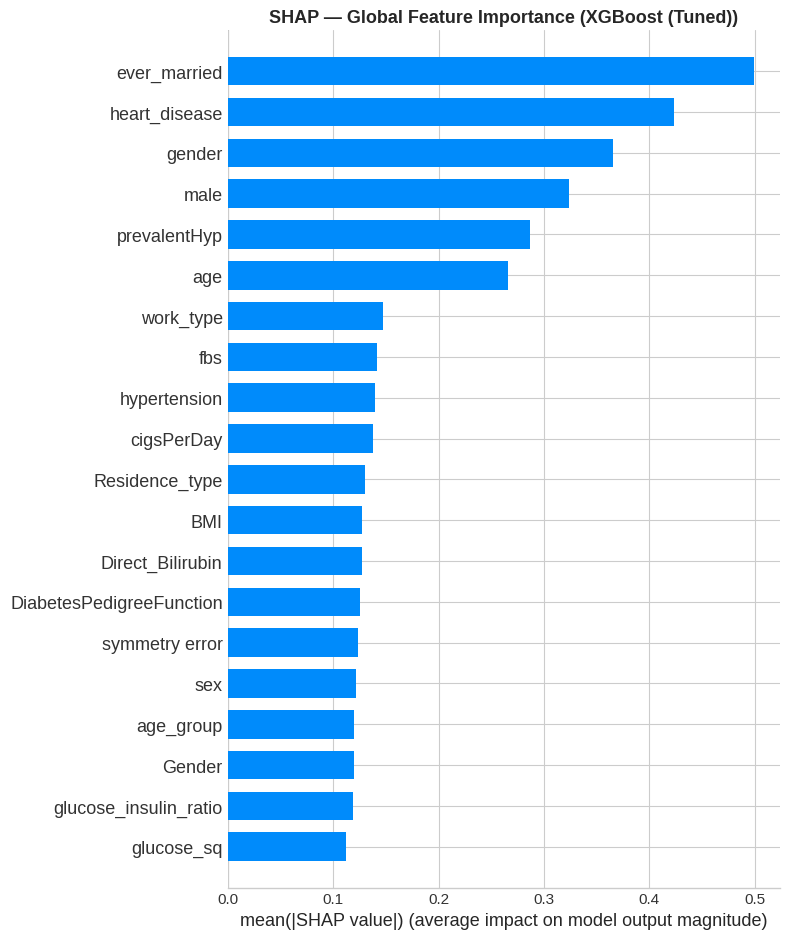

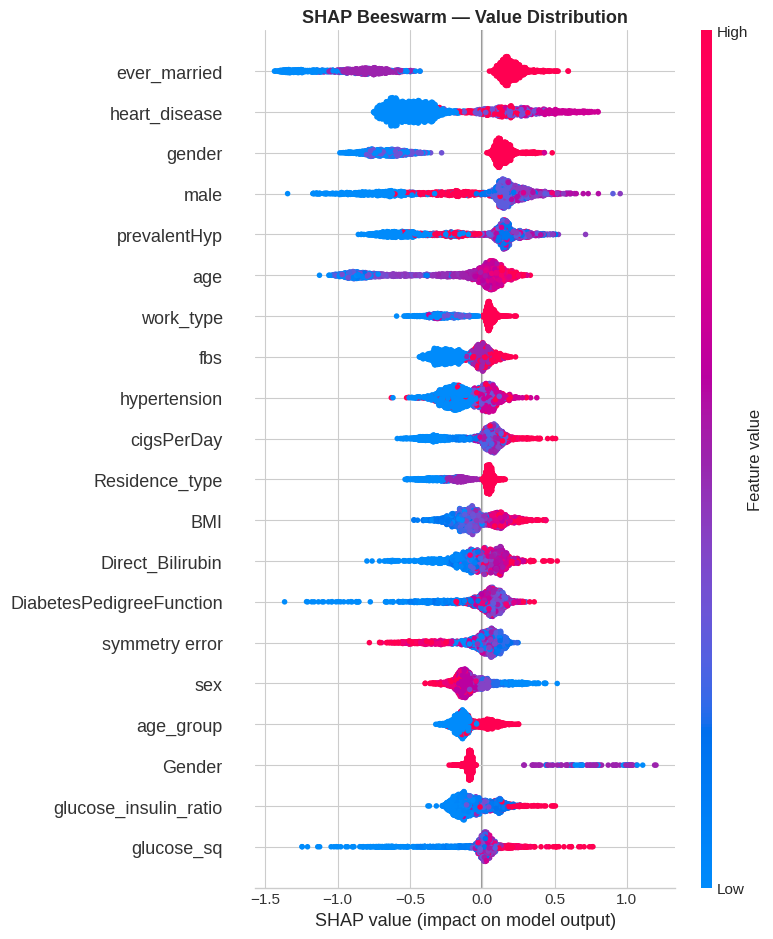

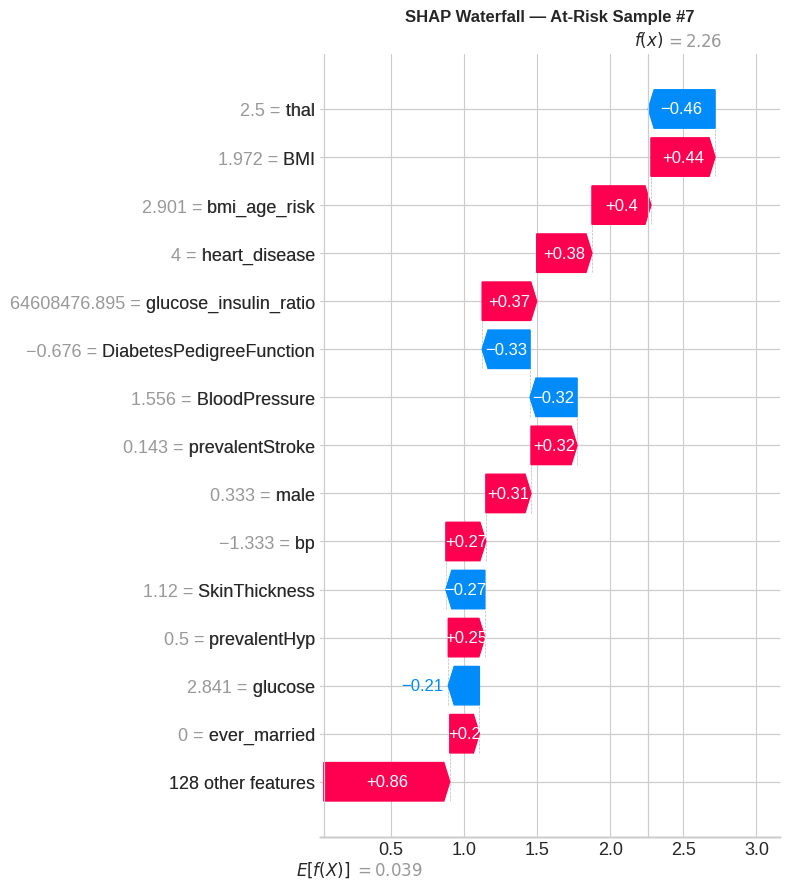

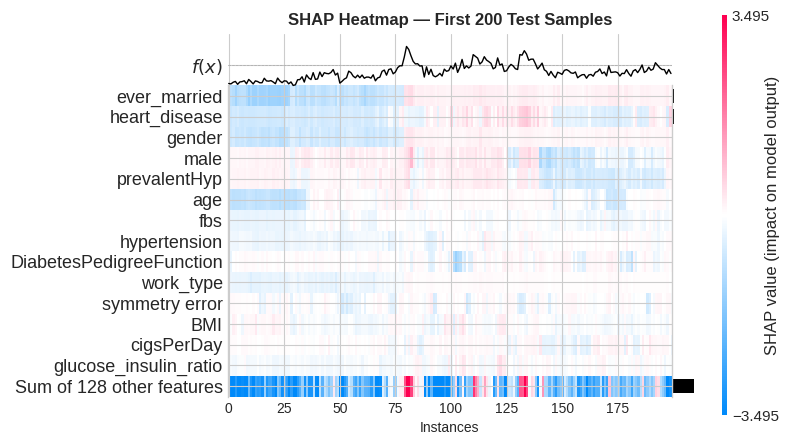

SHAP analysis complete — 4 plots saved.


In [13]:
# Pick best tree model for SHAP (TreeExplainer is fast & accurate)
tree_model_preference = ["XGBoost (Tuned)", "LightGBM (Tuned)", "CatBoost (Tuned)",
                          "XGBoost", "LightGBM", "CatBoost",
                          "Random Forest", "Extra Trees",
                          "Gradient Boosting"]
shap_model_name = next((n for n in tree_model_preference if n in trained_models),
                        best_name)
shap_mdl  = trained_models[shap_model_name]

print(f"  Computing SHAP — using {shap_model_name} …")
X_shap    = pd.DataFrame(X_test_s[:2000], columns=FEATURE_COLS)
explainer = shap.TreeExplainer(shap_mdl)
sv        = explainer.shap_values(X_shap)

# Handle binary vs multi-output
if isinstance(sv, list):
    sv = sv[1]

# Global mean |SHAP|
plt.figure(figsize=(11, 8))
shap.summary_plot(sv, X_shap, plot_type="bar", max_display=20, show=False)
plt.title(f"SHAP — Global Feature Importance ({shap_model_name})",
          fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("shap_01_bar.png", dpi=150, bbox_inches="tight")
plt.show()

# Beeswarm
plt.figure(figsize=(11, 8))
shap.summary_plot(sv, X_shap, max_display=20, show=False)
plt.title("SHAP Beeswarm — Value Distribution", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("shap_02_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

# Waterfall for a random at-risk sample
risk_idx = np.where(y_test[:2000] == 1)[0][0]
shap_exp  = shap.Explanation(
    values        = sv[risk_idx],
    base_values   = explainer.expected_value if not isinstance(
                        explainer.expected_value, (list,np.ndarray))
                    else explainer.expected_value[1],
    data          = X_shap.iloc[risk_idx].values,
    feature_names = FEATURE_COLS,
)
shap.waterfall_plot(shap_exp, max_display=15, show=False)
plt.title(f"SHAP Waterfall — At-Risk Sample #{risk_idx}", fontweight="bold")
plt.tight_layout()
plt.savefig("shap_03_waterfall.png", dpi=150, bbox_inches="tight")
plt.show()

# Heatmap
plt.figure(figsize=(13, 7))
shap.plots.heatmap(shap.Explanation(
    values        = sv[:200],
    base_values   = np.full(200, explainer.expected_value
                            if not isinstance(explainer.expected_value,
                                              (list,np.ndarray))
                            else explainer.expected_value[1]),
    data          = X_shap.iloc[:200].values,
    feature_names = FEATURE_COLS,
), max_display=15, show=False)
plt.title("SHAP Heatmap — First 200 Test Samples", fontweight="bold")
plt.tight_layout()
plt.savefig("shap_04_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

print("SHAP analysis complete — 4 plots saved.")

🏥 Per-Disease Performance Breakdown

In [14]:
print(f"\n{'='*72}")
print(f"  PER-DISEASE BREAKDOWN  —  {best_name}")
print(f"{'='*72}")

X_test_meta = X_test_raw.copy()
X_test_meta["__target__"]  = y_test
X_test_meta["__proba__"]   = results[best_name]["proba"]
X_test_meta["__pred__"]    = results[best_name]["pred"]
X_test_meta["__disease__"] = df.loc[X_test_raw.index, "disease"].values

breakdown = []
for disease, grp in X_test_meta.groupby("__disease__"):
    if grp["__target__"].nunique() < 2 or len(grp) < 10:
        continue
    try:
        d_auc = roc_auc_score(grp["__target__"], grp["__proba__"])
        d_acc = accuracy_score(grp["__target__"], grp["__pred__"])
        d_f1  = f1_score(grp["__target__"], grp["__pred__"], average="weighted")
        d_mcc = matthews_corrcoef(grp["__target__"], grp["__pred__"])
        d_bal = balanced_accuracy_score(grp["__target__"], grp["__pred__"])
        breakdown.append({"Disease":disease, "Samples":len(grp),
                           "Accuracy":d_acc, "ROC-AUC":d_auc,
                           "F1":d_f1, "MCC":d_mcc, "BalAcc":d_bal})
    except Exception:
        pass

bdf = pd.DataFrame(breakdown).sort_values("ROC-AUC", ascending=False)
print(bdf.to_string(index=False, float_format="{:.4f}".format))

fig = px.bar(bdf, x="Disease", y="ROC-AUC",
             color="ROC-AUC", color_continuous_scale="RdYlGn",
             text=bdf["ROC-AUC"].map("{:.3f}".format),
             title=f"<b>Per-Disease ROC-AUC — {best_name}</b>",
             height=440)
fig.update_traces(textposition="outside")
fig.update_layout(xaxis_tickangle=-25, coloraxis_showscale=False,
                  yaxis_range=[0, 1.05])
fig.show()


  PER-DISEASE BREAKDOWN  —  Voting Ensemble
               Disease  Samples  Accuracy  ROC-AUC     F1    MCC  BalAcc
Chronic Kidney Disease       80    1.0000   1.0000 1.0000 1.0000  1.0000
         Breast Cancer      128    0.9297   0.9835 0.9303 0.8549  0.9355
         Heart Disease       62    0.8065   0.8740 0.8065 0.6125  0.8063
              Diabetes      146    0.7534   0.8391 0.7509 0.4813  0.7358
   Parkinson's Disease       40    0.8000   0.8339 0.7933 0.4726  0.7210
                Stroke     1006    0.9503   0.8163 0.9305 0.1770  0.5284
         Liver Disease      110    0.7000   0.7504 0.6478 0.3087  0.6036
    Hypertension / CHD      862    0.8260   0.6704 0.7835 0.0516  0.5148


📉 Cross-Validation Stability (Top 8 Models)


⏳  Running 5-fold CV on top 8 models …
  Voting Ensemble               mean=0.9851  std=0.0008  min=0.9838  max=0.9860
  Random Forest                 mean=0.9816  std=0.0009  min=0.9805  max=0.9831
  Extra Trees                   mean=0.9882  std=0.0005  min=0.9877  max=0.9890
  LightGBM                      mean=0.9802  std=0.0015  min=0.9785  max=0.9831
  CatBoost                      mean=0.9767  std=0.0010  min=0.9755  max=0.9783
  Stacking Ensemble             mean=0.9893  std=0.0007  min=0.9883  max=0.9900
  LightGBM (Tuned)              mean=0.9804  std=0.0011  min=0.9792  max=0.9823
  XGBoost                       mean=0.9795  std=0.0013  min=0.9781  max=0.9819


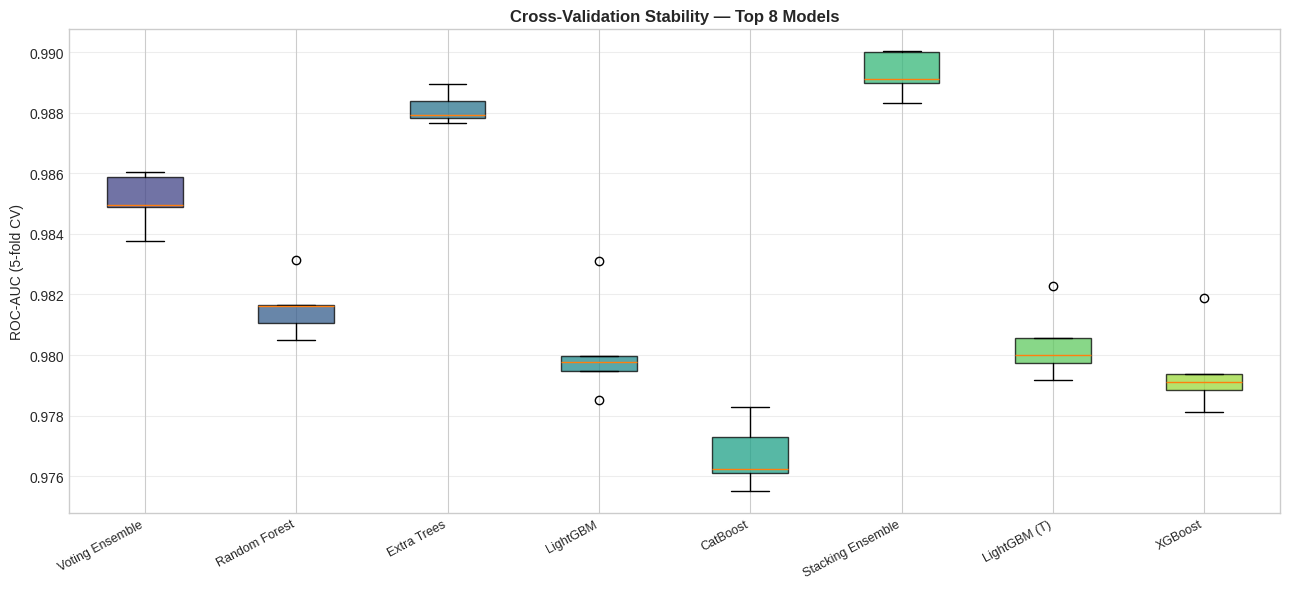

In [15]:
print("\n⏳  Running 5-fold CV on top 8 models …")
top8_names = [x[0] for x in sorted(results.items(),
              key=lambda x: x[1]["roc_auc"], reverse=True)[:8]]

cv_summary = {}
for name in top8_names:
    scores = cross_val_score(
        trained_models[name], X_train_bal, y_train_bal,
        cv=CV_SCORER, scoring="roc_auc", n_jobs=-1)
    cv_summary[name] = scores
    print(f"  {name:<28}  mean={scores.mean():.4f}  std={scores.std():.4f}  "
          f"min={scores.min():.4f}  max={scores.max():.4f}")

# Box plot
fig, ax = plt.subplots(figsize=(13, 6))
bp_data  = [cv_summary[n] for n in top8_names]
bp_names = [n.replace("(Tuned)","(T)") for n in top8_names]
bp = ax.boxplot(bp_data, patch_artist=True, vert=True, notch=False)
colors_cv = plt.cm.viridis(np.linspace(0.2, 0.85, len(top8_names)))
for patch, color in zip(bp["boxes"], colors_cv):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
ax.set_xticklabels(bp_names, rotation=28, ha="right", fontsize=9)
ax.set_ylabel("ROC-AUC (5-fold CV)")
ax.set_title("Cross-Validation Stability — Top 8 Models", fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))
ax.grid(True, axis="y", alpha=0.35)
plt.tight_layout()
plt.savefig("eval_04_cv_stability.png", dpi=150, bbox_inches="tight")
plt.show()

🩺 Patient Risk Prediction Engine

In [21]:
def risk_tier(prob):
    if prob < 0.25: return "🟢 LOW RISK",       "#4CAF50", 0
    if prob < 0.50: return "🟡 MODERATE RISK",   "#FFC107", 1
    if prob < 0.75: return "🟠 HIGH RISK",        "#FF5722", 2
    return               "🔴 CRITICAL RISK",    "#B71C1C", 3

TIER_ADVICE = {
    0: ["Continue healthy lifestyle — annual checkup is sufficient.",
        "Maintain balanced diet, regular exercise, 7-8 h sleep.",
        "No immediate medical intervention required."],
    1: ["Schedule a health check within 4 weeks.",
        "Review diet and physical activity habits.",
        "Monitor relevant biomarkers at home if possible."],
    2: ["Consult your physician within 1 week.",
        "Request comprehensive blood panel and imaging if advised.",
        "Strict adherence to any existing medications / lifestyle changes."],
    3: ["Seek immediate medical consultation today.",
        "Do not delay — bring all past reports for the physician.",
        "Emergency evaluation may be required depending on symptoms."],
}

def predict_patient(patient_dict: dict, show_report=True):
    """
    Parameters
    ----------
    patient_dict : dict  {feature_name: value}
    Returns      : dict  {risk_probability, risk_tier, shap_top5, recommendations}
    """
    # Build feature row
    row = {c: (X_train_raw[c].median() if c in X_train_raw.columns else 0)
           for c in FEATURE_COLS}
    row.update(patient_dict)
    row_df = pd.DataFrame([row])[FEATURE_COLS]

    # Encode categoricals
    for col in cat_cols:
        if col in row_df.columns and col in label_encoders:
            try:
                row_df[col] = label_encoders[col].transform(row_df[col].astype(str))
            except Exception:
                row_df[col] = 0

    row_s   = scaler.transform(row_df.values)
    prob    = float(best_model.predict_proba(row_s)[0][1])
    label, color, tier_idx = risk_tier(prob)

    # SHAP for this patient
    row_shap_df = pd.DataFrame(row_s, columns=FEATURE_COLS)
    sv_patient  = explainer.shap_values(row_shap_df)
    if isinstance(sv_patient, list):
        sv_patient = sv_patient[1]
    sv_series = pd.Series(sv_patient[0], index=FEATURE_COLS).abs().sort_values(ascending=False)
    top5_feats = sv_series.head(5).index.tolist()

    advice = TIER_ADVICE[tier_idx].copy()
    for feat in top5_feats[:3]:
        val = patient_dict.get(feat, "N/A")
        advice.append(f"• Monitor biomarker: {feat} (input = {val})")

    if show_report:
        w = 66
        print("╔" + "═"*(w-2) + "╗")
        print("║" + "  MULTI-DISEASE RISK FORECAST REPORT".center(w-2) + "║")
        print("╠" + "═"*(w-2) + "╣")
        print(f"║  Risk Probability  : {prob*100:>5.1f}%".ljust(w-1) + "║")
        print(f"║  Risk Level        : {label}".ljust(w-1) + "║")
        print(f"║  Model Used        : {best_name}".ljust(w-1) + "║")
        print("╠" + "═"*(w-2) + "╣")
        print("║  TOP 5 CONTRIBUTING BIOMARKERS:".ljust(w-1) + "║")
        for i, feat in enumerate(top5_feats, 1):
            sv_val = explainer.shap_values(row_shap_df)
            sv_val = sv_val[1][0] if isinstance(sv_val, list) else sv_val[0]
            direction = "↑ raises" if sv_val[FEATURE_COLS.index(feat)] > 0 else "↓ lowers"
            val = patient_dict.get(feat, "(imputed)")
            line = f"  {i}. {feat:<30} = {str(val):<8}  {direction} risk"
            print("║" + line.ljust(w-1) + "║")
        print("╠" + "═"*(w-2) + "╣")
        print("║  RECOMMENDATIONS:".ljust(w-1) + "║")
        for rec in advice:
            for chunk in [rec[j:j+w-5] for j in range(0, len(rec), w-5)]:
                print("║  " + chunk.ljust(w-3) + "║")
        print("╠" + "═"*(w-2) + "╣")
        print("║  ⚠  DISCLAIMER: Screening tool only.".ljust(w-1) + "║")
        print("║     Always consult a licensed medical professional.".ljust(w-1) + "║")
        print("╚" + "═"*(w-2) + "╝")

    return dict(risk_probability=round(prob*100, 2), risk_level=label,
                shap_top5=top5_feats, recommendations=advice)

# ── Demo: Diabetic risk profile ────────────────────────────────────────────
demo1 = dict(Pregnancies=6, Glucose=148, BloodPressure=72, SkinThickness=35,
             Insulin=200, BMI=33.6, DiabetesPedigreeFunction=0.627, Age=50)
out1 = predict_patient(demo1)

# ── Demo: Cardiac risk profile ─────────────────────────────────────────────
demo2 = dict(age=62, sex=1, cp=0, trestbps=145, chol=240, fbs=1,
             restecg=1, thalach=130, exang=1, oldpeak=2.3,
             slope=2, ca=3, thal=3)
print("\n")
out2 = predict_patient(demo2)

╔════════════════════════════════════════════════════════════════╗
║                MULTI-DISEASE RISK FORECAST REPORT              ║
╠════════════════════════════════════════════════════════════════╣
║  Risk Probability  :  23.0%                                    ║
║  Risk Level        : 🟢 LOW RISK                                ║
║  Model Used        : Voting Ensemble                           ║
╠════════════════════════════════════════════════════════════════╣
║  TOP 5 CONTRIBUTING BIOMARKERS:                                ║
║  1. Gender                         = (imputed)  ↑ raises risk   ║
║  2. ever_married                   = (imputed)  ↓ lowers risk   ║
║  3. gender                         = (imputed)  ↓ lowers risk   ║
║  4. heart_disease                  = (imputed)  ↓ lowers risk   ║
║  5. Residence_type                 = (imputed)  ↓ lowers risk   ║
╠════════════════════════════════════════════════════════════════╣
║  RECOMMENDATIONS:                                      

📊 Interactive Risk Dashboard (Plotly)

In [22]:
def render_dashboard(patient_dict, result_dict, model_lb_df):
    prob      = result_dict["risk_probability"] / 100
    label     = result_dict["risk_level"]
    top5      = result_dict["shap_top5"]
    recs      = result_dict["recommendations"]

    g_color   = ("#B71C1C" if prob >= 0.75 else "#FF5722" if prob >= 0.50
                 else "#FFC107" if prob >= 0.25 else "#4CAF50")

    fig = make_subplots(
        rows=3, cols=2,
        subplot_titles=(
            "Disease Risk Gauge",
            "SHAP — Top 10 Feature Contributions",
            "Model Leaderboard (ROC-AUC)",
            "Per-Disease Performance",
            "Risk Probability Scale",
            "Patient Input Summary",
        ),
        specs=[
            [{"type":"indicator"}, {"type":"bar"}],
            [{"type":"bar"},       {"type":"bar"}],
            [{"type":"bar"},       {"type":"table"}],
        ],
        vertical_spacing=0.12, horizontal_spacing=0.1,
        row_heights=[0.34, 0.33, 0.33],
    )

    # Gauge
    fig.add_trace(go.Indicator(
        mode="gauge+number+delta",
        value=round(prob * 100, 1),
        number={"suffix":"%","font":{"size":40}},
        delta={"reference":50, "increasing":{"color":"#E53935"},
               "decreasing":{"color":"#4CAF50"}},
        gauge=dict(
            axis=dict(range=[0,100], tickwidth=1, tickcolor="darkgrey"),
            bar=dict(color=g_color, thickness=0.4),
            steps=[dict(range=[0,25],  color="#C8E6C9"),
                   dict(range=[25,50], color="#FFF9C4"),
                   dict(range=[50,75], color="#FFE0B2"),
                   dict(range=[75,100],color="#FFCDD2")],
            threshold=dict(line=dict(color="black", width=4), value=50),
        ),
        title={"text": f"Risk Score<br><sup>{label}</sup>"},
    ), row=1, col=1)

    # SHAP bar (recompute for patient)
    row_s_dash = scaler.transform(
        pd.DataFrame([{**{c: X_train_raw[c].median()
                          for c in FEATURE_COLS}, **patient_dict}])[FEATURE_COLS].values)
    sv_d = explainer.shap_values(pd.DataFrame(row_s_dash, columns=FEATURE_COLS))
    if isinstance(sv_d, list): sv_d = sv_d[1]
    sv_series = pd.Series(sv_d[0], index=FEATURE_COLS).sort_values(key=abs, ascending=False).head(10)
    bar_colors = ["#E53935" if v > 0 else "#1E88E5" for v in sv_series.values]
    fig.add_trace(go.Bar(x=sv_series.values, y=sv_series.index,
                          orientation="h", marker_color=bar_colors,
                          hovertemplate="%{y}: %{x:.3f}<extra></extra>",
                          name="SHAP"), row=1, col=2)

    # Leaderboard
    lb_top8 = model_lb_df.head(8)
    fig.add_trace(go.Bar(x=lb_top8["ROC-AUC"], y=lb_top8["Model"],
                          orientation="h",
                          marker_color=px.colors.sequential.Viridis[::-1][:8],
                          text=lb_top8["ROC-AUC"].map("{:.3f}".format),
                          textposition="outside",
                          name="AUC"), row=2, col=1)

    # Per-disease
    fig.add_trace(go.Bar(x=bdf["ROC-AUC"].values, y=bdf["Disease"].values,
                          orientation="h",
                          marker_color=px.colors.diverging.RdYlGn[:len(bdf)],
                          text=bdf["ROC-AUC"].map("{:.3f}".format),
                          textposition="outside",
                          name="Disease AUC"), row=2, col=2)

    # Risk scale
    scale_w = [25, 25, 25, 25]
    scale_l = ["Low", "Moderate", "High", "Critical"]
    scale_c = ["#4CAF50","#FFC107","#FF5722","#B71C1C"]
    for w_, l_, c_ in zip(scale_w, scale_l, scale_c):
        fig.add_trace(go.Bar(x=[w_], y=["Risk"], orientation="h",
                              marker_color=c_, name=l_, showlegend=True,
                              hovertemplate=f"{l_}<extra></extra>"), row=3, col=1)
    fig.add_trace(go.Scatter(x=[prob*100], y=["Risk"], mode="markers",
                              marker=dict(symbol="triangle-down", size=20,
                                          color="black", line=dict(width=1)),
                              name=f"Your score: {prob*100:.1f}%",
                              showlegend=True), row=3, col=1)

    # Patient table
    pt_feats = [k for k in patient_dict if k in FEATURE_COLS]
    fig.add_trace(go.Table(
        header=dict(values=["Feature","Input Value"],
                    fill_color="#1565C0", font_color="white",
                    align="left", height=26),
        cells=dict(values=[[k for k in pt_feats],
                            [str(patient_dict[k]) for k in pt_feats]],
                   fill_color=["#E3F2FD","#F3F3F3"],
                   align="left", height=22)
    ), row=3, col=2)

    fig.update_layout(
        height=980, width=1150,
        title_text="<b>Multi-Disease Risk Forecast — Interactive Dashboard</b>",
        title_font_size=17,
        paper_bgcolor="white",
        plot_bgcolor="#FAFAFA",
        showlegend=True,
        legend=dict(x=0.01, y=0.15, font_size=9),
    )
    return fig

dash_fig = render_dashboard(demo1, out1, lb)
dash_fig.show()
dash_fig.write_html("risk_dashboard.html")
print("  Dashboard saved → risk_dashboard.html")

  Dashboard saved → risk_dashboard.html


💾 Save Artefacts & Download

In [23]:
import shutil

os.makedirs("artefacts", exist_ok=True)

joblib.dump(best_model,     "artefacts/best_model.pkl")
joblib.dump(scaler,         "artefacts/scaler.pkl")
joblib.dump(imputer,        "artefacts/imputer.pkl")
joblib.dump(label_encoders, "artefacts/label_encoders.pkl")
joblib.dump(disease_le,     "artefacts/disease_label_encoder.pkl")
joblib.dump(explainer,      "artefacts/shap_explainer.pkl")

# Save leaderboard
lb.to_csv("artefacts/model_leaderboard.csv", index=False)
bdf.to_csv("artefacts/per_disease_breakdown.csv", index=False)

meta = {
    "best_model_name"   : best_name,
    "feature_cols"      : FEATURE_COLS,
    "disease_names"     : DISEASE_NAMES,
    "n_diseases"        : len(DISEASE_NAMES),
    "n_total_samples"   : int(len(combined)),
    "best_roc_auc"      : float(results[best_name]["roc_auc"]),
    "best_accuracy"     : float(results[best_name]["accuracy"]),
    "best_f1"           : float(results[best_name]["f1"]),
    "best_mcc"          : float(results[best_name]["mcc"]),
    "all_model_results" : {k: {m: float(v) for m, v in res.items()
                               if m not in ("proba","pred")}
                           for k, res in results.items()},
}
with open("artefacts/meta.json", "w") as f:
    json.dump(meta, f, indent=2)

shutil.make_archive("MultiDiseaseRiskForecast_v2_artefacts", "zip", "artefacts")

try:
    from google.colab import files
    files.download("MultiDiseaseRiskForecast_v2_artefacts.zip")
    files.download("risk_dashboard.html")
except Exception:
    print("  (Not running in Colab — artefacts saved locally)")

print("\n" + "═"*60)
print("  🎉  PIPELINE COMPLETE")
print("═"*60)
print(f"  Best Model       : {best_name}")
print(f"  ROC-AUC          : {results[best_name]['roc_auc']:.4f}")
print(f"  Accuracy         : {results[best_name]['accuracy']:.4f}")
print(f"  F1-Score         : {results[best_name]['f1']:.4f}")
print(f"  MCC              : {results[best_name]['mcc']:.4f}")
print(f"  Balanced Acc     : {results[best_name]['bal_acc']:.4f}")
print(f"  Diseases Covered : {len(combined['disease'].unique())}")
print(f"  Total Samples    : {len(combined):,}")
print(f"  Total Models     : {len(results)}")
print("═"*60)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


════════════════════════════════════════════════════════════
  🎉  PIPELINE COMPLETE
════════════════════════════════════════════════════════════
  Best Model       : Voting Ensemble
  ROC-AUC          : 0.8792
  Accuracy         : 0.8776
  F1-Score         : 0.8711
  MCC              : 0.5761
  Balanced Acc     : 0.7590
  Diseases Covered : 8
  Total Samples    : 12,168
  Total Models     : 21
════════════════════════════════════════════════════════════


♻️ Standalone Inference Template

In [24]:
"""
Run this cell independently after downloading artefacts.
Just load the zip, unzip, and call infer().
"""

def infer(patient_dict: dict) -> dict:
    """
    Predict disease risk from a dict of lab values.

    Parameters
    ----------
    patient_dict : {feature_name: value}
                   Any subset of features is fine — the rest are median-imputed.

    Returns
    -------
    dict with keys:
        risk_probability  (float, 0–100)
        risk_level        (str)
        top_features      (list[str])
    """
    import joblib, json, pandas as pd, numpy as np

    model_  = joblib.load("artefacts/best_model.pkl")
    scaler_ = joblib.load("artefacts/scaler.pkl")
    le_map_ = joblib.load("artefacts/label_encoders.pkl")
    with open("artefacts/meta.json") as f_:
        meta_ = json.load(f_)

    FEAT_ = meta_["feature_cols"]
    row_  = {c: 0 for c in FEAT_}
    row_.update(patient_dict)
    row_df = pd.DataFrame([row_])[FEAT_]

    for col, le_ in le_map_.items():
        if col in row_df.columns:
            try:    row_df[col] = le_.transform(row_df[col].astype(str))
            except: row_df[col] = 0

    row_s_ = scaler_.transform(row_df.values)
    prob_  = float(model_.predict_proba(row_s_)[0][1])

    tiers_ = [(0.25,"🟢 LOW RISK"),(0.50,"🟡 MODERATE RISK"),
               (0.75,"🟠 HIGH RISK"),(1.01,"🔴 CRITICAL RISK")]
    level_ = next(lbl for thresh, lbl in tiers_ if prob_ < thresh)

    return {"risk_probability": round(prob_*100, 2), "risk_level": level_}

# Quick test
test_p = dict(Glucose=170, BMI=34, Age=55, BloodPressure=85, Insulin=220)
print("Inference test:", infer(test_p))

Inference test: {'risk_probability': 15.67, 'risk_level': '🟢 LOW RISK'}
